# STATS 426 – Music Hit Prediction: Final Model Notebook
  
**Primary metric:** AUPRC (Area Under the Precision-Recall Curve) — optimal for
heavily imbalanced binary classification.  
Secondary metrics: ROC-AUC, F1 (at val-tuned threshold), Precision, Recall.

### Models compared
| # | Model | Notes |
|---|-------|-------|
| 1 | Logistic Regression | Interpretable baseline |
| 2 | XGBoost | Strong gradient-boosted baseline |
| 3 | TabNet (CV-tuned) | Attentive tabular DL |
| 4 | Wide & Deep NN + Genre Embeddings | End-to-end deep model |

## 0  Installs & Imports

In [1]:

!pip install pytorch-tabnet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.5 MB/s eta 0:00:00


In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# XGBoost
from xgboost import XGBClassifier

# TabNet
from pytorch_tabnet.tab_model import TabNetClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 1  Data Loading & Cleaning
Ethan's pipeline: load → aggregate chart data → define hit label → select audio features → clean.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving audio_features.csv to audio_features.csv
Saving leader_board.csv to leader_board.csv


In [4]:
#os.rename("audio_features (1).csv", "audio_features.csv")
#os.rename("leader_board (1).csv",   "leader_board.csv")

audio = pd.read_csv("audio_features.csv")
lb    = pd.read_csv("leader_board.csv")

print(audio.head())
print(lb.head())

   index                                             SongID  \
0      0     -twistin'-White Silver SandsBill Black's Combo   
1      1  ¿Dònde Està Santa Claus? (Where Is Santa Claus...   
2      2             ......And Roses And RosesAndy Williams   
3      3           ...And Then There Were DrumsSandy Nelson   
4      4                ...Baby One More TimeBritney Spears   

            Performer                                              Song  \
0  Bill Black's Combo                      -twistin'-White Silver Sands   
1          Augie Rios  ¿Dònde Està Santa Claus? (Where Is Santa Claus?)   
2       Andy Williams                         ......And Roses And Roses   
3        Sandy Nelson                      ...And Then There Were Drums   
4      Britney Spears                             ...Baby One More Time   

                                       spotify_genre        spotify_track_id  \
0                                                 []                     NaN   
1         

In [5]:
# Aggregate weekly chart data to song level
lb["WeekID"] = pd.to_datetime(lb["WeekID"], format="%m/%d/%Y", errors="coerce")

lb_song = (
    lb.groupby("SongID", as_index=False)
      .agg(
          first_week      = ("WeekID",         "min"),
          last_week       = ("WeekID",         "max"),
          peak_position   = ("Peak Position",  "min"),   # lower is better
          weeks_on_chart  = ("Weeks on Chart", "max"),
      )
      .assign(
          # HIT DEFINITION: Top-10 peak AND ≥ 15 weeks on chart
          hit=lambda d: (
              (d.peak_position <= 10) & (d.weeks_on_chart >= 15)
          ).astype(int)
      )
)

print(f"Songs in leaderboard: {len(lb_song):,}")
print(f"Hit rate: {lb_song['hit'].mean()*100:.2f}%")

Songs in leaderboard: 29,389
Hit rate: 13.05%


In [6]:
#  Select and clean audio features
AUDIO_COLS = [
    "SongID", "spotify_genre", "spotify_track_duration_ms",
    "spotify_track_explicit", "danceability", "energy", "key",
    "loudness", "mode", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo", "time_signature"
]
audio = audio[AUDIO_COLS].dropna()

# bool to int
audio["spotify_track_explicit"] = audio["spotify_track_explicit"].astype(int)

print(f"Audio rows after cleaning: {len(audio):,}")

Audio rows after cleaning: 24,186


## 2  Genre Encoding
Build a vocabulary, encode each song's genre list as integer IDs, and pre-compute
**frozen** mean-pooled embeddings (used by tree-based models and TabNet as numeric
features).  The neural network will **re-learn** its own genre embeddings end-to-end.

In [7]:
# Normalise genre strings
def normalize_genres(x):
    if x == "[]" or pd.isna(x):
        return ["unknown"]
    try:
        return ast.literal_eval(x)
    except Exception:
        return ["unknown"]

audio["spotify_genre"] = audio["spotify_genre"].apply(normalize_genres)

# Build vocabulary
PAD, UNK   = "<PAD>", "<UNK>"
all_genres = sorted({g for genres in audio["spotify_genre"] for g in genres})

genre2idx = {PAD: 0, UNK: 1}
for g in all_genres:
    if g not in genre2idx:
        genre2idx[g] = len(genre2idx)

vocab_size = len(genre2idx)
MAX_GENRES = 5

print(f"Genre vocab size: {vocab_size:,}")

# Encode genres as padded integer sequences
def encode_genres(genres):
    ids = [genre2idx.get(g, genre2idx[UNK]) for g in genres][:MAX_GENRES]
    ids += [genre2idx[PAD]] * (MAX_GENRES - len(ids))
    return ids

audio["spotify_genre_ids"] = audio["spotify_genre"].apply(encode_genres)

Genre vocab size: 1,045


In [8]:
#Pre-compute FROZEN mean-pooled genre embeddings (for non-NN models)
EMBED_DIM = 16

class GenreEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

    def forward(self, genre_ids):
        e    = self.emb(genre_ids)                                     # (N, MAX_GENRES, D)
        mask = (genre_ids != self.pad_idx).unsqueeze(-1).float()      # (N, MAX_GENRES, 1)
        e    = e * mask
        denom  = mask.sum(dim=1).clamp(min=1.0)                       # (N, 1)
        return e.sum(dim=1) / denom                                    # (N, D)

genre_encoder = GenreEncoder(vocab_size, EMBED_DIM)

genre_ids_tensor = torch.tensor(
    pd.DataFrame(audio["spotify_genre_ids"].to_list()).values,
    dtype=torch.long
)

with torch.no_grad():
    genre_vecs = genre_encoder(genre_ids_tensor).numpy()

genre_emb_df = pd.DataFrame(
    genre_vecs,
    columns=[f"genre_emb_{i+1}" for i in range(EMBED_DIM)],
    index=audio.index
)

audio = pd.concat([audio, genre_emb_df], axis=1)
print("Genre embeddings attached. audio.shape:", audio.shape)

Genre embeddings attached. audio.shape: (24186, 33)


## 3  Merge & Feature Engineering

In [9]:
#  Merge audio + chart data
df = audio.merge(lb_song, on="SongID", how="inner")
df = df.sort_values("first_week").reset_index(drop=True)

print(f"Merged dataset: {df.shape}")
print(f"Hit rate: {df['hit'].mean()*100:.2f}%")
print(f"Date range: {df['first_week'].min().date()} → {df['last_week'].max().date()}")

Merged dataset: (24185, 38)
Hit rate: 14.30%
Date range: 1958-08-02 → 2021-05-29


In [10]:
#Feature engineering
# Interaction features (Ethan's originals + extras)
df["energy_x_dance"]    = df["energy"]      * df["danceability"]
df["valence_x_energy"]  = df["valence"]     * df["energy"]
df["tempo_x_energy"]    = df["tempo"]       * df["energy"]
df["loudness_abs"]      = df["loudness"].abs()

# Additional meaningful interactions
df["acoustic_x_vocal"]  = df["acousticness"] * df["speechiness"]   # acoustic vocal style
df["dance_x_valence"]   = df["danceability"]  * df["valence"]       # upbeat danceable
df["energy_sq"]         = df["energy"] ** 2                         # non-linear energy
df["tempo_norm"]        = df["tempo"] / 200.0                       # normalise BPM

print("Feature engineering done. New columns added.")
df.isnull().sum()[df.isnull().sum() > 0]

Feature engineering done. New columns added.


,0


## 4  Train / Val / Test Split (70 / 15 / 15, stratified)
> **Note:** `first_week`, `last_week`, `peak_position`, and `weeks_on_chart` are ALL
> dropped — they would constitute label leakage (they're derived from the same chart
> data used to define the hit label).

In [11]:
# Columns to exclude from features
LEAK_COLS = [
    "SongID", "hit",
    "peak_position", "weeks_on_chart",   # leakage — used to define 'hit'
    "first_week", "last_week",           # date metadata, not audio features
    "spotify_genre", "spotify_genre_ids" # non-numeric, raw genre data
]

# Feature matrix for tree-based models & TabNet (numeric only)
X_tab = df.drop(columns=LEAK_COLS).select_dtypes(include=[np.number])
y     = df["hit"]

print(f"Feature matrix shape: {X_tab.shape}")
print(f"Features: {list(X_tab.columns)}")

#Preserve genre_ids separately for the end-to-end NN
genre_ids_all = np.stack(df["spotify_genre_ids"].values)  # (N, MAX_GENRES)

#  70 / 30 first split
(X_train, X_temp,
 g_train, g_temp,
 y_train, y_temp) = train_test_split(
    X_tab.values, genre_ids_all, y.values,
    test_size=0.30, random_state=426, stratify=y
)

# 30-->15 val / 15 test
(X_val, X_test,
 g_val, g_test,
 y_val, y_test) = train_test_split(
    X_temp, g_temp, y_temp,
    test_size=0.50, random_state=426, stratify=y_temp
)

for split, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{split}: {len(yy):,} samples | hit rate: {yy.mean()*100:.2f}%")

Feature matrix shape: (24185, 38)
Features: ['spotify_track_duration_ms', 'spotify_track_explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'genre_emb_1', 'genre_emb_2', 'genre_emb_3', 'genre_emb_4', 'genre_emb_5', 'genre_emb_6', 'genre_emb_7', 'genre_emb_8', 'genre_emb_9', 'genre_emb_10', 'genre_emb_11', 'genre_emb_12', 'genre_emb_13', 'genre_emb_14', 'genre_emb_15', 'genre_emb_16', 'energy_x_dance', 'valence_x_energy', 'tempo_x_energy', 'loudness_abs', 'acoustic_x_vocal', 'dance_x_valence', 'energy_sq', 'tempo_norm']
Train: 16,929 samples | hit rate: 14.30%
Val: 3,628 samples | hit rate: 14.31%
Test: 3,628 samples | hit rate: 14.31%


## 5  Preprocessing
**Critical fix from Daniel's notebook:** `scaler.fit_transform` was called on the
validation and test sets — this leaks test distribution information.  
We `fit` only on training data and `transform` all others.

In [12]:
# tandardScaler fit on TRAIN only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)    # ← FIX: was fit_transform in Daniel's nb
X_test_s  = scaler.transform(X_test)  # ← FIX: was fit_transform in Daniel's nb

input_dim = X_train_s.shape[1]
print(f"Input dimension: {input_dim}")

Input dimension: 38


## 6  Evaluation Utilities
A unified `evaluate()` function used by every model:
- Finds the **F1-optimal threshold** on the *validation* set  
- Reports AUPRC (primary), ROC-AUC, F1, Precision, Recall, Accuracy on the *test* set

In [13]:
def find_best_threshold(y_true, y_prob):
    """Return the probability threshold that maximises F1 on a validation set."""
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-8)
    best_idx = np.argmax(f1s[:-1])   # last element has no corresponding threshold
    return float(thresh[best_idx])


def evaluate(model_name, y_val, val_probs, y_test, test_probs, show_cm=True):
    """
    Param

    y_val, val_probs   : validation labels + predicted probabilities (for threshold tuning)
    y_test, test_probs : test labels + predicted probabilities (for final metrics)
    """
    # threshold tuned on val set trff
    thresh = find_best_threshold(y_val, val_probs)

    #  test set metrics
    preds  = (test_probs >= thresh).astype(int)

    auprc  = average_precision_score(y_test, test_probs)
    roc    = roc_auc_score(y_test, test_probs)
    f1     = f1_score(y_test, preds)
    prec   = precision_score(y_test, preds, zero_division=0)
    rec    = recall_score(y_test, preds, zero_division=0)
    acc    = accuracy_score(y_test, preds)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  AUPRC  (primary) : {auprc:.4f}")
    print(f"  ROC-AUC          : {roc:.4f}")
    print(f"  F1 (thresh={thresh:.3f}): {f1:.4f}")
    print(f"  Precision        : {prec:.4f}")
    print(f"  Recall           : {rec:.4f}")
    print(f"  Accuracy         : {acc:.4f}")
    print(f"{'='*50}")

    if show_cm:
        cm = confusion_matrix(y_test, preds)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Confusion matrix
        ConfusionMatrixDisplay(cm, display_labels=["Non-Hit","Hit"]).plot(ax=axes[0], colorbar=False)
        axes[0].set_title(f"{model_name} – Confusion Matrix")

        # Precision-Recall curve
        prec_c, rec_c, _ = precision_recall_curve(y_test, test_probs)
        baseline = y_test.mean()
        axes[1].plot(rec_c, prec_c, lw=2, label=f"AUPRC = {auprc:.3f}")
        axes[1].axhline(baseline, linestyle="--", color="gray", label=f"Random = {baseline:.3f}")
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].set_title(f"{model_name} – Precision-Recall Curve")
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    return dict(model=model_name, AUPRC=auprc, ROC_AUC=roc, F1=f1,
                Precision=prec, Recall=rec, Accuracy=acc, Threshold=thresh)

results_summary = []   # collect results from every model

## 7  Model 1: Logistic Regression (Baseline)


  Logistic Regression
  AUPRC  (primary) : 0.2532
  ROC-AUC          : 0.6816
  F1 (thresh=0.509): 0.3256
  Precision        : 0.2220
  Recall           : 0.6108
  Accuracy         : 0.6381


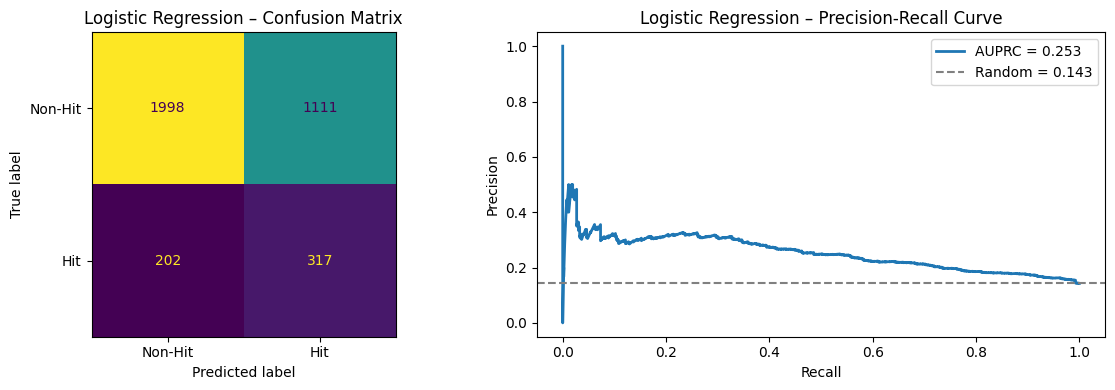

In [14]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=10_000,
    solver="lbfgs",
    C=0.1,             # mild regularisation WEEWOOOWEOO
    random_state=426
)
lr_model.fit(X_train_s, y_train)

val_probs_lr  = lr_model.predict_proba(X_val_s)[:, 1]
test_probs_lr = lr_model.predict_proba(X_test_s)[:, 1]

res = evaluate("Logistic Regression", y_val, val_probs_lr, y_test, test_probs_lr)
results_summary.append(res)

## 8  Model 2: XGBoost
`scale_pos_weight` corrects class imbalance; `eval_metric='aucpr'` aligns training
with our primary metric (AUPRC). Early stopping on the validation set prevents
overfitting without needing to pre-specify n_estimators.

scale_pos_weight = 5.99  (neg/pos = 14508/2421)
Best iteration: 269

  XGBoost
  AUPRC  (primary) : 0.3187
  ROC-AUC          : 0.7183
  F1 (thresh=0.512): 0.3577
  Precision        : 0.2705
  Recall           : 0.5279
  Accuracy         : 0.7288


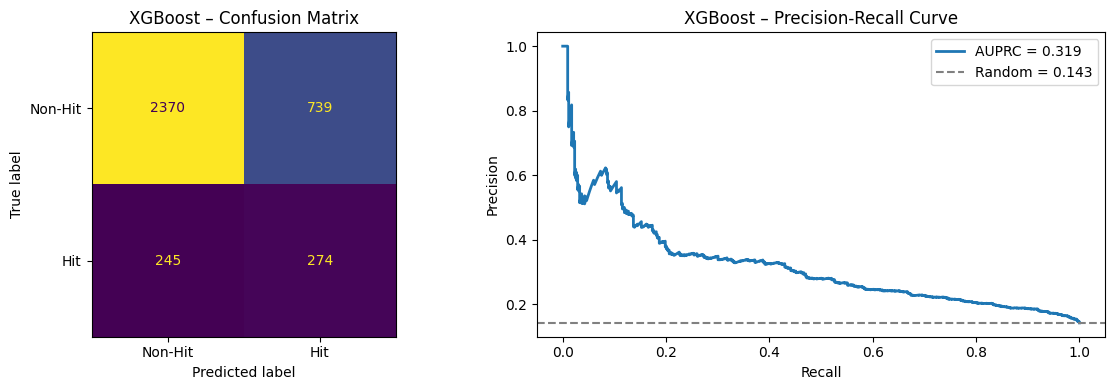

In [15]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.2f}  (neg/pos = {neg}/{pos})")

xgb_model = XGBClassifier(
    n_estimators        = 1000,
    learning_rate       = 0.05,
    max_depth           = 5,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_weight    = 3,
    scale_pos_weight    = spw,
    eval_metric         = "aucpr",   # optimise AUPRC (our primary metric)
    early_stopping_rounds = 30,
    random_state        = 426,
    use_label_encoder   = False
)

xgb_model.fit(
    X_train_s, y_train,
    eval_set    = [(X_val_s, y_val)],
    verbose     = False
)

print(f"Best iteration: {xgb_model.best_iteration}")

val_probs_xgb  = xgb_model.predict_proba(X_val_s)[:, 1]
test_probs_xgb = xgb_model.predict_proba(X_test_s)[:, 1]

res = evaluate("XGBoost", y_val, val_probs_xgb, y_test, test_probs_xgb)
results_summary.append(res)

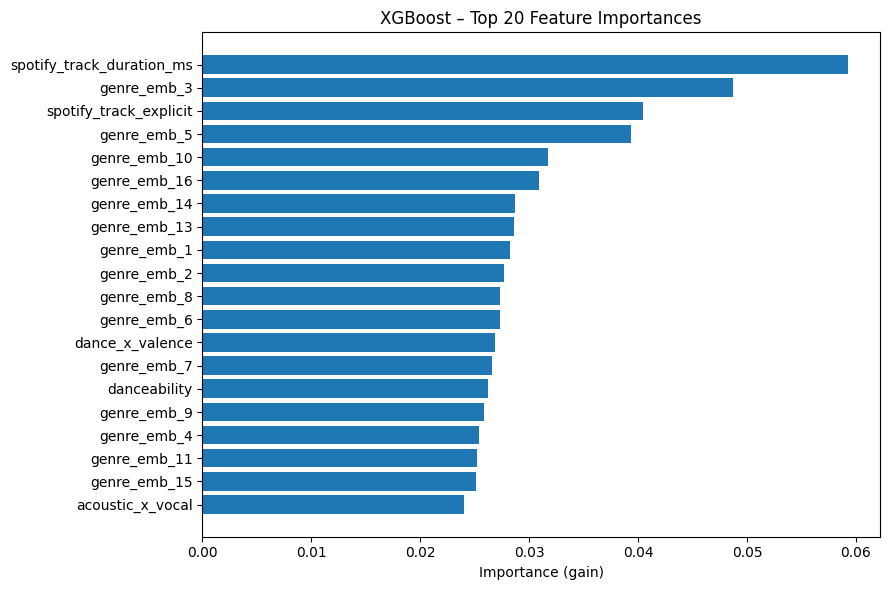

In [16]:
# XGBoost feature importance
feat_names = X_tab.columns.tolist()
importances = xgb_model.feature_importances_

top_n = 20
sorted_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(9, 6))
plt.barh(
    [feat_names[i] for i in sorted_idx[::-1]],
    importances[sorted_idx[::-1]]
)
plt.xlabel("Importance (gain)")
plt.title(f"XGBoost – Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()

## 9  Model 3: TabNet (with Cross-Validation Hyperparameter Search)
From the TabNet notebook:  
1. Grid-search a small set of configurations using 5-fold stratified CV on the training set.  
2. Retrain the best config on all training data (90%) with a small held-out val set (10%) for early stopping.  
3. Evaluate on the untouched test set.

In [17]:
# TabNet configs to grid-search
TABNET_CONFIGS = [
    dict(n_d=32, n_a=32, n_steps=5, gamma=1.5, lambda_sparse=1e-3, lr=1e-3),
    dict(n_d=32, n_a=32, n_steps=6, gamma=1.5, lambda_sparse=1e-3, lr=1e-3),
    dict(n_d=32, n_a=32, n_steps=5, gamma=1.8, lambda_sparse=1e-2, lr=1e-3),
    dict(n_d=32, n_a=32, n_steps=5, gamma=1.5, lambda_sparse=0,    lr=1e-3),
    dict(n_d=64, n_a=64, n_steps=5, gamma=1.5, lambda_sparse=1e-3, lr=1e-3),
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=426)

cv_results = []

for ci, cfg in enumerate(TABNET_CONFIGS, 1):
    fold_auprcs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_s, y_train), 1):
        Xf_tr, Xf_val = X_train_s[tr_idx], X_train_s[val_idx]
        yf_tr, yf_val = y_train[tr_idx],   y_train[val_idx]

        tb = TabNetClassifier(
            n_d            = cfg["n_d"],
            n_a            = cfg["n_a"],
            n_steps        = cfg["n_steps"],
            gamma          = cfg["gamma"],
            lambda_sparse  = cfg["lambda_sparse"],
            optimizer_fn   = torch.optim.AdamW,
            optimizer_params = dict(lr=cfg["lr"], weight_decay=1e-5),
            mask_type      = "entmax",
            device_name    = device,
            verbose        = 0
        )

        tb.fit(
            Xf_tr, yf_tr,
            eval_set      = [(Xf_val, yf_val)],
            eval_metric   = ["auc"],
            max_epochs    = 100,
            patience      = 10,
            batch_size    = 1024,
            virtual_batch_size = 128,
            drop_last     = False
        )

        proba = tb.predict_proba(Xf_val)[:, 1]
        auprc = average_precision_score(yf_val, proba)
        fold_auprcs.append(auprc)
        print(f"  Config {ci}/{len(TABNET_CONFIGS)} | Fold {fold} AUPRC: {auprc:.4f}")

    mean_ap = float(np.mean(fold_auprcs))
    std_ap  = float(np.std(fold_auprcs))
    cv_results.append((ci, cfg, mean_ap, std_ap))
    print(f"  → Config {ci} mean AUPRC: {mean_ap:.4f} ± {std_ap:.4f}\n")


Early stopping occurred at epoch 66 with best_epoch = 56 and best_val_0_auc = 0.6588
  Config 1/5 | Fold 1 AUPRC: 0.2332

Early stopping occurred at epoch 60 with best_epoch = 50 and best_val_0_auc = 0.65226
  Config 1/5 | Fold 2 AUPRC: 0.2195

Early stopping occurred at epoch 68 with best_epoch = 58 and best_val_0_auc = 0.67236
  Config 1/5 | Fold 3 AUPRC: 0.2429

Early stopping occurred at epoch 30 with best_epoch = 20 and best_val_0_auc = 0.62103
  Config 1/5 | Fold 4 AUPRC: 0.2072

Early stopping occurred at epoch 41 with best_epoch = 31 and best_val_0_auc = 0.64161
  Config 1/5 | Fold 5 AUPRC: 0.2164
  → Config 1 mean AUPRC: 0.2239 ± 0.0127


Early stopping occurred at epoch 92 with best_epoch = 82 and best_val_0_auc = 0.65097
  Config 2/5 | Fold 1 AUPRC: 0.2539

Early stopping occurred at epoch 35 with best_epoch = 25 and best_val_0_auc = 0.60606
  Config 2/5 | Fold 2 AUPRC: 0.1945

Early stopping occurred at epoch 43 with best_epoch = 33 and best_val_0_auc = 0.62745
  Config 2/

In [18]:
#Summary of CV results
cv_sorted = sorted(cv_results, key=lambda x: x[2], reverse=True)
print("===== CV Summary (best → worst) =====")
for ci, cfg, mean_ap, std_ap in cv_sorted:
    print(f"Config {ci}: AUPRC {mean_ap:.4f} ± {std_ap:.4f} | {cfg}")

best_ci, best_cfg, best_cv_auprc, _ = cv_sorted[0]
print(f"\nSelected: Config {best_ci} | CV AUPRC = {best_cv_auprc:.4f}")

===== CV Summary (best → worst) =====
Config 5: AUPRC 0.2432 ± 0.0110 | {'n_d': 64, 'n_a': 64, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 0.001, 'lr': 0.001}
Config 4: AUPRC 0.2258 ± 0.0114 | {'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 0, 'lr': 0.001}
Config 3: AUPRC 0.2239 ± 0.0176 | {'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': 1.8, 'lambda_sparse': 0.01, 'lr': 0.001}
Config 1: AUPRC 0.2239 ± 0.0127 | {'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 0.001, 'lr': 0.001}
Config 2: AUPRC 0.2161 ± 0.0221 | {'n_d': 32, 'n_a': 32, 'n_steps': 6, 'gamma': 1.5, 'lambda_sparse': 0.001, 'lr': 0.001}

Selected: Config 5 | CV AUPRC = 0.2432



Early stopping occurred at epoch 109 with best_epoch = 94 and best_val_0_auc = 0.69151

  TabNet (CV-tuned)
  AUPRC  (primary) : 0.2493
  ROC-AUC          : 0.6598
  F1 (thresh=0.126): 0.3109
  Precision        : 0.2066
  Recall           : 0.6281
  Accuracy         : 0.6017


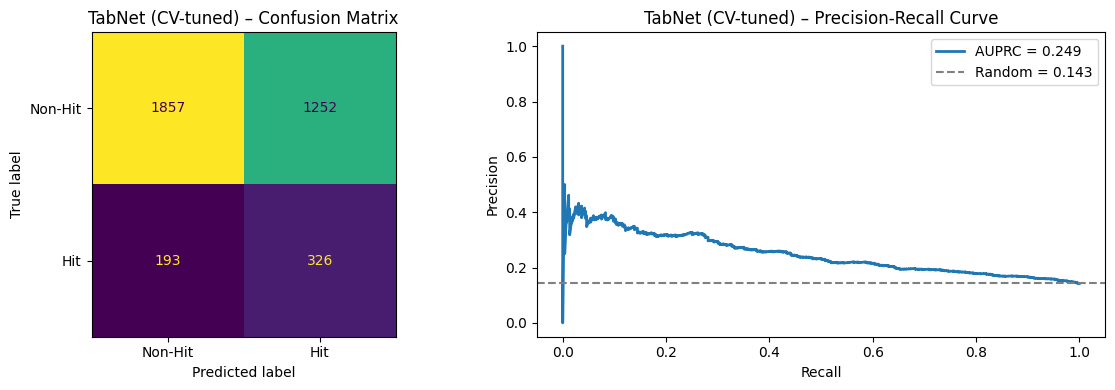

In [19]:
#Final TabNet: train on 90% of training data, 10% for early-stop
Xtn_tr, Xtn_val, ytn_tr, ytn_val = train_test_split(
    X_train_s, y_train,
    test_size=0.10, random_state=426, stratify=y_train
)

final_tabnet = TabNetClassifier(
    n_d           = best_cfg["n_d"],
    n_a           = best_cfg["n_a"],
    n_steps       = best_cfg["n_steps"],
    gamma         = best_cfg["gamma"],
    lambda_sparse = best_cfg["lambda_sparse"],
    optimizer_fn  = torch.optim.AdamW,
    optimizer_params = dict(lr=best_cfg["lr"], weight_decay=1e-5),
    mask_type     = "entmax",
    device_name   = device,
    verbose       = 0
)

final_tabnet.fit(
    Xtn_tr, ytn_tr,
    eval_set       = [(Xtn_val, ytn_val)],
    eval_metric    = ["auc"],
    max_epochs     = 200,
    patience       = 15,
    batch_size     = 1024,
    virtual_batch_size = 128,
    drop_last      = False
)

val_probs_tn  = final_tabnet.predict_proba(X_val_s)[:, 1]
test_probs_tn = final_tabnet.predict_proba(X_test_s)[:, 1]

res = evaluate("TabNet (CV-tuned)", y_val, val_probs_tn, y_test, test_probs_tn)
results_summary.append(res)

## 10  Model 4: Wide & Deep Neural Network + End-to-End Genre Embeddings

Architecture combines the best elements from Ethan's notebook:
- **Wide path**: a linear layer that reads the combined input directly (memorisation)
- **Deep path**: residual blocks with BatchNorm and Dropout (generalisation)
- **Genre embeddings**: trained end-to-end (not frozen) via a trainable `nn.Embedding`

Training improvements:
- Mini-batch `DataLoader` (from Daniel's notebook — avoids full-batch gradient issues)
- `BCEWithLogitsLoss(pos_weight=...)` for imbalance
- `ReduceLROnPlateau` scheduler
- Gradient clipping (essential with residual connections)
- Early stopping on **validation AUPRC** (aligns stopping criterion with primary metric)

In [20]:
# Tensors for the W&D NN
Xt_tr = torch.tensor(X_train_s, dtype=torch.float32)
Xt_va = torch.tensor(X_val_s,   dtype=torch.float32)
Xt_te = torch.tensor(X_test_s,  dtype=torch.float32)

Xg_tr = torch.tensor(g_train, dtype=torch.long)
Xg_va = torch.tensor(g_val,   dtype=torch.long)
Xg_te = torch.tensor(g_test,  dtype=torch.long)

yt_tr = torch.tensor(y_train, dtype=torch.float32)
yt_va = torch.tensor(y_val,   dtype=torch.float32)
yt_te = torch.tensor(y_test,  dtype=torch.float32)

BATCH_SIZE = 512

train_loader = DataLoader(TensorDataset(Xt_tr, Xg_tr, yt_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xt_va, Xg_va, yt_va), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(Xt_te, Xg_te, yt_te), batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


In [21]:
#  Model definition

class ResidualBlock(nn.Module):
    """Pre-activation residual block with BatchNorm + Dropout."""
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )

    def forward(self, x):
        return x + self.block(x)   # skip connection


class WideDeepHitPredictor(nn.Module):
    """
    Wide & Deep model with learnable genre embeddings.
    - Wide: linear(combined_dim → 1)
    - Deep: Linear projection → 2 × ResidualBlock → head
    - Genre: end-to-end nn.Embedding, mean-pooled across MAX_GENRES slots
    """
    def __init__(self, numeric_dim, vocab_size, embed_dim=EMBED_DIM,
                 hidden_dim=256, pad_idx=0):
        super().__init__()

        self.genre_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        combined_dim   = numeric_dim + embed_dim

        # Wide component
        self.wide = nn.Linear(combined_dim, 1)

        #  Deep component
        self.input_proj = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )
        self.res1 = ResidualBlock(hidden_dim, dropout=0.35)
        self.res2 = ResidualBlock(hidden_dim, dropout=0.25)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x_num, x_genre):
        # mean-pool genre embeddings (masking handled by padding_idx=0 → zero vec)
        g = self.genre_emb(x_genre).mean(dim=1)   # (B, embed_dim)
        x = torch.cat([x_num, g], dim=1)           # (B, numeric_dim + embed_dim)

        wide_out = self.wide(x)                    # (B, 1)
        deep_out = self.head(self.res2(self.res1(self.input_proj(x))))  # (B, 1)

        return wide_out + deep_out                 # logits


nn_model = WideDeepHitPredictor(
    numeric_dim = input_dim,
    vocab_size  = vocab_size,
    embed_dim   = EMBED_DIM,
    hidden_dim  = 256
).to(device)

total_params = sum(p.numel() for p in nn_model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

Model parameters: 313,096


In [22]:
# Loss, optimiser, scheduler
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.AdamW(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.5   # 'max' because we watch AUPRC
)

#  Training loop
EPOCHS   = 100
PATIENCE = 12

best_val_auprc = -1.0
best_state     = None
patience_ctr   = 0
train_losses, val_auprcs = [], []

for epoch in range(1, EPOCHS + 1):

    #Train
    nn_model.train()
    epoch_loss = 0.0
    for xb, gb, yb in train_loader:
        xb, gb, yb = xb.to(device), gb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(nn_model(xb, gb).squeeze(), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(nn_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    # Validate
    nn_model.eval()
    all_vprobs, all_vlabels = [], []
    with torch.no_grad():
        for xb, gb, yb in val_loader:
            xb, gb = xb.to(device), gb.to(device)
            probs = torch.sigmoid(nn_model(xb, gb).squeeze()).cpu().numpy()
            all_vprobs.extend(probs)
            all_vlabels.extend(yb.numpy())

    val_auprc = average_precision_score(all_vlabels, all_vprobs)
    val_auprcs.append(val_auprc)
    scheduler.step(val_auprc)

    # Early stopping (on val AUPRC)
    if val_auprc > best_val_auprc:
        best_val_auprc = val_auprc
        best_state     = {k: v.cpu().clone() for k, v in nn_model.state_dict().items()}
        patience_ctr   = 0
    else:
        patience_ctr += 1

    if epoch % 10 == 0:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:3d} | train loss: {epoch_loss:.4f} | "
              f"val AUPRC: {val_auprc:.4f} | best: {best_val_auprc:.4f} | lr: {lr_now:.2e}")

    if patience_ctr >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

nn_model.load_state_dict(best_state)
print(f"\nBest val AUPRC: {best_val_auprc:.4f}")

Epoch  10 | train loss: 0.9313 | val AUPRC: 0.2802 | best: 0.2884 | lr: 1.00e-03
Epoch  20 | train loss: 0.7977 | val AUPRC: 0.2749 | best: 0.2910 | lr: 5.00e-04
Early stopping at epoch 25.

Best val AUPRC: 0.2910


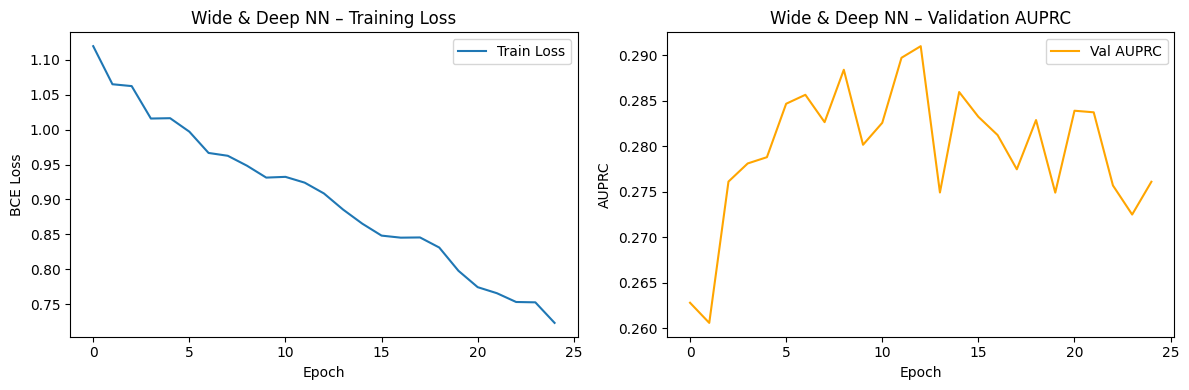

In [23]:
# Training curve wee woo weee woo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.set_title("Wide & Deep NN – Training Loss")
ax1.legend()

ax2.plot(val_auprcs, color="orange", label="Val AUPRC")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("AUPRC")
ax2.set_title("Wide & Deep NN – Validation AUPRC")
ax2.legend()

plt.tight_layout(); plt.show()


  Wide & Deep NN + Genre Embeddings
  AUPRC  (primary) : 0.2938
  ROC-AUC          : 0.7142
  F1 (thresh=0.614): 0.3514
  Precision        : 0.2695
  Recall           : 0.5048
  Accuracy         : 0.7335


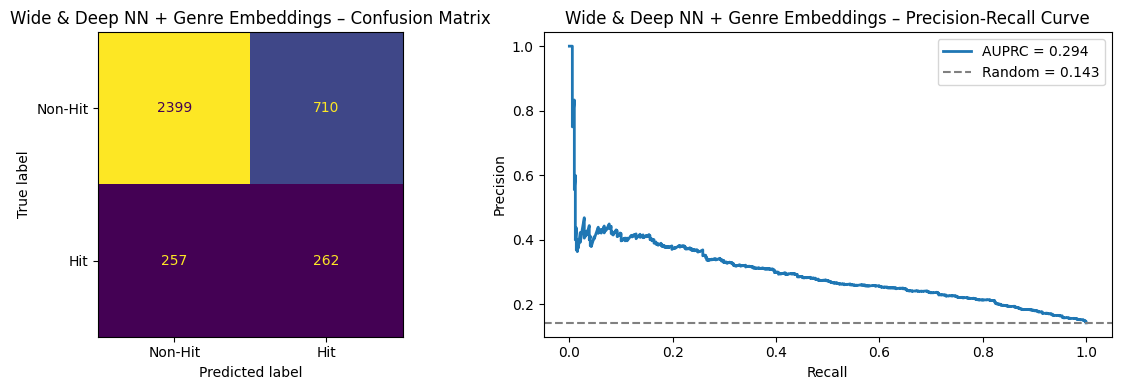

In [24]:
# Test evaluation type shi
nn_model.eval()
nn_model.to(device)

all_vprobs_nn, all_tprobs_nn = [], []

with torch.no_grad():
    for xb, gb, yb in val_loader:
        xb, gb = xb.to(device), gb.to(device)
        p = torch.sigmoid(nn_model(xb, gb).squeeze()).cpu().numpy()
        all_vprobs_nn.extend(p)

    for xb, gb, yb in test_loader:
        xb, gb = xb.to(device), gb.to(device)
        p = torch.sigmoid(nn_model(xb, gb).squeeze()).cpu().numpy()
        all_tprobs_nn.extend(p)

res = evaluate(
    "Wide & Deep NN + Genre Embeddings",
    y_val,  np.array(all_vprobs_nn),
    y_test, np.array(all_tprobs_nn)
)
results_summary.append(res)

## 11  Model Comparison

                                    AUPRC  ROC_AUC      F1  Precision  Recall  Accuracy  Threshold
model                                                                                             
XGBoost                            0.3187   0.7183  0.3577     0.2705  0.5279    0.7288     0.5116
Wide & Deep NN + Genre Embeddings  0.2938   0.7142  0.3514     0.2695  0.5048    0.7335     0.6141
Logistic Regression                0.2532   0.6816  0.3256     0.2220  0.6108    0.6381     0.5093
TabNet (CV-tuned)                  0.2493   0.6598  0.3109     0.2066  0.6281    0.6017     0.1264


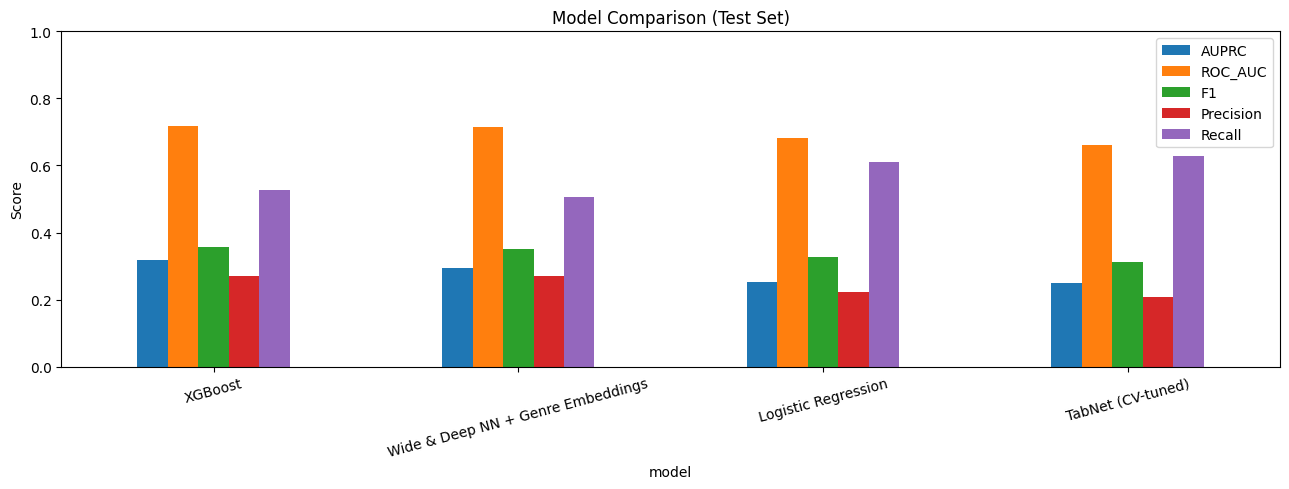

In [25]:
summary_df = pd.DataFrame(results_summary).set_index("model")
summary_df = summary_df.sort_values("AUPRC", ascending=False)
print(summary_df.round(4).to_string())

# Bar chart
metrics = ["AUPRC", "ROC_AUC", "F1", "Precision", "Recall"]
summary_df[metrics].plot(
    kind="bar", figsize=(13, 5), rot=15
)
plt.title("Model Comparison (Test Set)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Interpretation
- **AUPRC** is the primary metric because the dataset is heavily imbalanced (~14 % hits).
  A random classifier achieves AUPRC ≈ class prevalence; anything substantially above
  that indicates real discriminative power.
- All thresholds are tuned on the **validation set** by maximising F1, then applied to
  the **held-out test set** — no test-set information is used to pick the threshold.
- The Wide & Deep NN benefits from **end-to-end genre embeddings**, while XGBoost and
  TabNet receive pre-engineered numeric features including frozen genre embeddings.

In [26]:
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.5 MB/s eta 0:00:00


13 Model 5: LightGBM
LightGBM grows trees leaf-wise (best-first) rather than level-wise like XGBoost, which lets it find deeper, more specialised splits faster. Key advantages here:

metric='average_precision' — training is directly aligned with our primary metric (AUPRC)
is_unbalance=True — auto-reweights positive/negative samples
early_stopping_rounds on val AUPRC — stops exactly when generalisation peaks
Categorical support: genre embeddings are passed as numeric here, but LightGBM could also handle raw category codes natively in an extension

[100]	valid_0's average_precision: 0.310589
[200]	valid_0's average_precision: 0.319392
Best iteration: 194

  LightGBM
  AUPRC  (primary) : 0.3216
  ROC-AUC          : 0.7197
  F1 (thresh=0.510): 0.3582
  Precision        : 0.2851
  Recall           : 0.4817
  Accuracy         : 0.7530


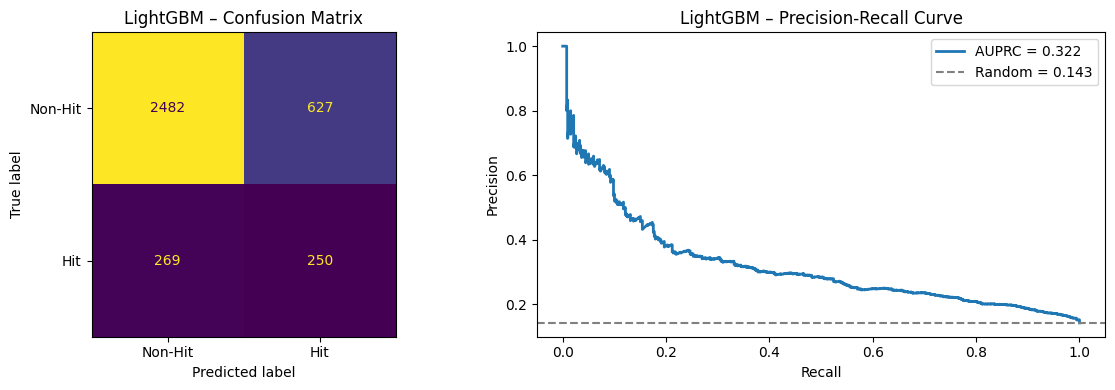

In [27]:
import lightgbm as lgb

# ── LightGBM datasets ────────────────────────────────────────────────────────
dtrain = lgb.Dataset(X_train_s, label=y_train)
dval   = lgb.Dataset(X_val_s,   label=y_val,   reference=dtrain)

lgb_params = {
    "objective"        : "binary",
    "metric"           : "average_precision",  # AUPRC — our primary metric
    "verbosity"        : -1,
    "learning_rate"    : 0.03,
    "num_leaves"       : 63,           # 2^max_depth - 1; more expressive than XGB default
    "max_depth"        : -1,           # no depth cap, controlled by num_leaves
    "min_child_samples": 20,           # prevents tiny leaf overfitting
    "feature_fraction" : 0.8,          # column subsampling per tree
    "bagging_fraction" : 0.8,          # row subsampling
    "bagging_freq"     : 5,
    "lambda_l1"        : 0.1,
    "lambda_l2"        : 1.0,
    "is_unbalance"     : True,         # auto pos/neg reweighting
    "seed"             : 426,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

lgb_model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round     = 2000,
    valid_sets          = [dval],
    callbacks           = callbacks,
)

print(f"Best iteration: {lgb_model.best_iteration}")

val_probs_lgb  = lgb_model.predict(X_val_s)
test_probs_lgb = lgb_model.predict(X_test_s)

res = evaluate("LightGBM", y_val, val_probs_lgb, y_test, test_probs_lgb)
results_summary.append(res)

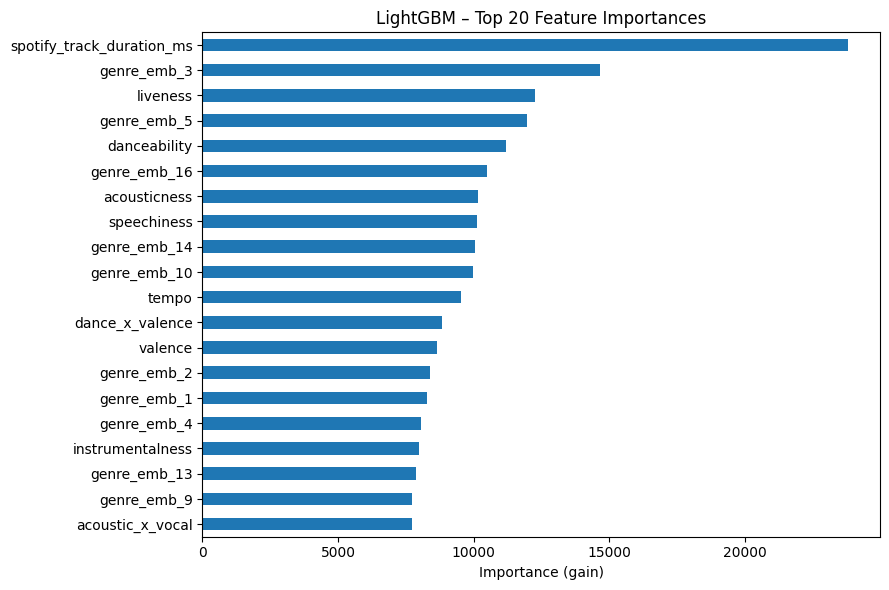

In [28]:
#LightGBM feature importance
lgb_imp = pd.Series(
    lgb_model.feature_importance(importance_type="gain"),
    index=X_tab.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 6))
lgb_imp[::-1].plot(kind="barh")
plt.xlabel("Importance (gain)")
plt.title("LightGBM – Top 20 Feature Importances")
plt.tight_layout()
plt.show()

14 Model 6: CatBoost
CatBoost uses ordered boosting (trains on a permutation of the data to avoid target leakage inside boosting) and symmetric trees (oblivious decision trees) which generalise better and are less prone to overfitting. Reasons to include it:

Often outperforms both XGBoost and LightGBM on mid-sized tabular datasets
auto_class_weights='Balanced' handles imbalance natively
Built-in overfitting detector on the validation set
Different inductive bias from LightGBM --> complementary errors --> better ensembling

0:	learn: 0.6695526	test: 0.6349960	best: 0.6349960 (0)	total: 57.6ms	remaining: 1m 55s
200:	learn: 0.8212627	test: 0.6897195	best: 0.6901205 (194)	total: 1.99s	remaining: 17.8s
400:	learn: 0.8900871	test: 0.6960572	best: 0.6961090 (396)	total: 3.93s	remaining: 15.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6968143085
bestIteration = 413

Shrink model to first 414 iterations.
Best iteration: 413

  CatBoost
  AUPRC  (primary) : 0.3187
  ROC-AUC          : 0.7227
  F1 (thresh=0.506): 0.3627
  Precision        : 0.2703
  Recall           : 0.5511
  Accuracy         : 0.7230


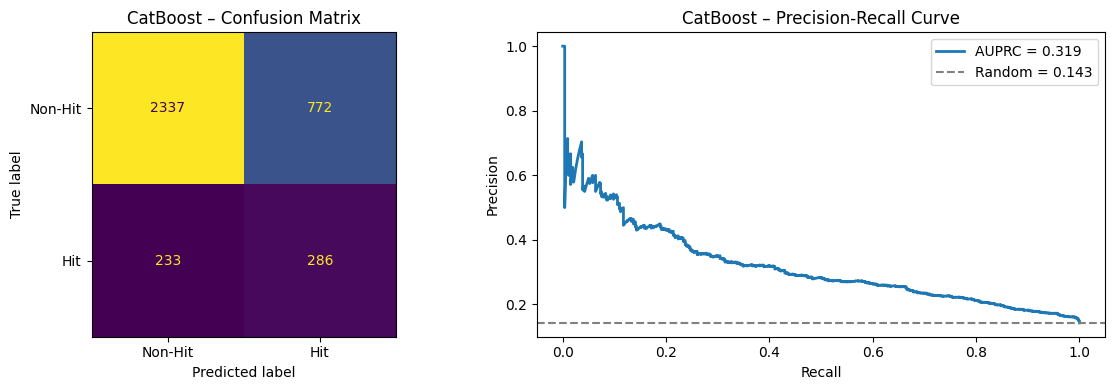

In [29]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations          = 2000,
    learning_rate       = 0.03,
    depth               = 7,
    l2_leaf_reg         = 3.0,
    subsample           = 0.8,
    colsample_bylevel   = 0.8,
    auto_class_weights  = "Balanced",   # handles imbalance
    eval_metric         = "PRAUC",      # AUPRC — our primary metric
    early_stopping_rounds = 50,
    random_seed         = 426,
    verbose             = 200,
    use_best_model      = True,
)

cat_model.fit(
    X_train_s, y_train,
    eval_set   = (X_val_s, y_val),
    plot       = False,
)

print(f"Best iteration: {cat_model.best_iteration_}")

val_probs_cat  = cat_model.predict_proba(X_val_s)[:, 1]
test_probs_cat = cat_model.predict_proba(X_test_s)[:, 1]

res = evaluate("CatBoost", y_val, val_probs_cat, y_test, test_probs_cat)
results_summary.append(res)

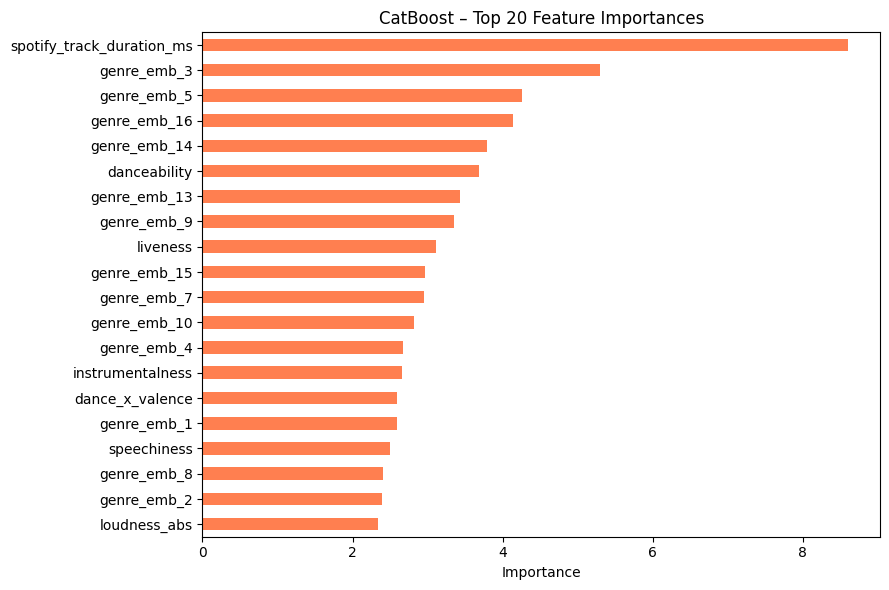

In [30]:
#CatBoost feature importance
cat_imp = pd.Series(
    cat_model.get_feature_importance(),
    index=X_tab.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 6))
cat_imp[::-1].plot(kind="barh", color="coral")
plt.xlabel("Importance")
plt.title("CatBoost – Top 20 Feature Importances")
plt.tight_layout()
plt.show()

## 15  Model 7: Stacking Ensemble (Out-of-Fold Meta-Learner)

A stacking ensemble trains a **meta-learner** on the predictions of the base models.
The critical detail: the meta-learner must be trained on **out-of-fold (OOF)**
predictions predictions made by a model that never saw that row during training.
This prevents the meta-learner from just learning to trust whichever base model overfit
the most.

### Pipeline
1. Split training data into 5 stratified folds
2. For each fold: train each base model on the other 4 folds --> predict on the held-out fold --> collect OOF probabilities
3. Stack OOF predictions as new features --> train a Logistic Regression meta-learner
4. For the test set: average each base model's predictions across all 5 fold-models --> feed into meta-learner

### Base models in the stack
| Model | Why included |
|-------|-------------|
| LightGBM | Best individual AUPRC, leaf-wise trees |
| CatBoost | Ordered boosting, different inductive bias |
| XGBoost | Level-wise trees, different error pattern |
| Logistic Regression | Linear baseline adds calibration signal |
| TabNet | Attention-based, captures feature interactions differently |

> The Wide & Deep NN is excluded from the OOF stack because re-training it 5× would
> be very slow in Colab. Its test probabilities are still used in the **simple average**
> ensemble below for comparison.

In [31]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression as MetaLR

#Base model factory functions (fresh model each fold)
def make_lgb():
    return lgb.LGBMClassifier(
        n_estimators       = 1000,
        learning_rate      = 0.03,
        num_leaves         = 63,
        min_child_samples  = 20,
        feature_fraction   = 0.8,
        bagging_fraction   = 0.8,
        bagging_freq       = 5,
        lambda_l1          = 0.1,
        lambda_l2          = 1.0,
        is_unbalance       = True,
        metric             = "average_precision",
        verbosity          = -1,
        random_state       = 426,
    )

def make_xgb(spw):
    return XGBClassifier(
        n_estimators          = 500,
        learning_rate         = 0.05,
        max_depth             = 5,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 3,
        scale_pos_weight      = spw,
        eval_metric           = "aucpr",
        early_stopping_rounds = 40,
        use_label_encoder     = False,
        random_state          = 426,
        verbosity             = 0,
    )

def make_cat():
    return CatBoostClassifier(
        iterations            = 500,
        learning_rate         = 0.05,
        depth                 = 7,
        l2_leaf_reg           = 3.0,
        auto_class_weights    = "Balanced",
        eval_metric           = "PRAUC",
        random_seed           = 426,
        verbose               = 0,
        use_best_model        = False,   # no eval set in fold training :C
    )

def make_lr():
    return MetaLR(
        class_weight = "balanced",
        max_iter     = 10_000,
        C            = 0.1,
        solver       = "lbfgs",
        random_state = 426,
    )

BASE_MODEL_NAMES = ["lgb", "xgb", "cat", "lr"]

# OOF setup meow
N_FOLDS = 5
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=426)

oof_preds  = np.zeros((len(X_train_s), len(BASE_MODEL_NAMES)))   # (N_train, 4)
test_preds = np.zeros((len(X_test_s),  len(BASE_MODEL_NAMES)))   # (N_test, 4)

neg_tr = (y_train == 0).sum()
pos_tr = (y_train == 1).sum()
spw    = neg_tr / pos_tr

print(f"Running {N_FOLDS}-fold OOF stacking with {len(BASE_MODEL_NAMES)} base models...")
print(f"scale_pos_weight = {spw:.2f}\n")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_s, y_train), 1):
    Xf_tr, Xf_val = X_train_s[tr_idx], X_train_s[val_idx]
    yf_tr, yf_val = y_train[tr_idx],   y_train[val_idx]

    print(f"Fold {fold}/{N_FOLDS} —", end=" ")

    # LightGBM
    m_lgb = make_lgb()
    m_lgb.fit(
        Xf_tr, yf_tr,
        eval_set              = [(Xf_val, yf_val)],
        callbacks             = [lgb.early_stopping(40, verbose=False),
                                  lgb.log_evaluation(-1)]
    )
    oof_preds[val_idx, 0]  = m_lgb.predict_proba(Xf_val)[:, 1]
    test_preds[:, 0]      += m_lgb.predict_proba(X_test_s)[:, 1] / N_FOLDS
    print("LGB ✓", end=" ")

    # XGBoost
    m_xgb = make_xgb(spw)
    m_xgb.fit(
    Xf_tr, yf_tr,
    eval_set  = [(Xf_val, yf_val)],
    verbose   = False
    )
    oof_preds[val_idx, 1]  = m_xgb.predict_proba(Xf_val)[:, 1]
    test_preds[:, 1]      += m_xgb.predict_proba(X_test_s)[:, 1] / N_FOLDS
    print("XGB ✓", end=" ")

    # CatBoost
    m_cat = make_cat()
    m_cat.fit(Xf_tr, yf_tr)
    oof_preds[val_idx, 2]  = m_cat.predict_proba(Xf_val)[:, 1]
    test_preds[:, 2]      += m_cat.predict_proba(X_test_s)[:, 1] / N_FOLDS
    print("CAT ✓", end=" ")

    # Logistic Regression
    m_lr = make_lr()
    m_lr.fit(Xf_tr, yf_tr)
    oof_preds[val_idx, 3]  = m_lr.predict_proba(Xf_val)[:, 1]
    test_preds[:, 3]      += m_lr.predict_proba(X_test_s)[:, 1] / N_FOLDS
    print("LR ✓")

    # OOF AUPRC for this fold
    fold_auprc = average_precision_score(yf_val, oof_preds[val_idx, 0])
    print(f"         Fold {fold} LGB OOF AUPRC: {fold_auprc:.4f}\n")

# OOF AUPRC per base model
print("\n===== OOF AUPRC per base model =====")
for i, name in enumerate(BASE_MODEL_NAMES):
    ap = average_precision_score(y_train, oof_preds[:, i])
    print(f"  {name:<6}: {ap:.4f}")

Running 5-fold OOF stacking with 4 base models...
scale_pos_weight = 5.99

Fold 1/5 — LGB ✓ XGB ✓ CAT ✓ LR ✓
         Fold 1 LGB OOF AUPRC: 0.3021

Fold 2/5 — LGB ✓ XGB ✓ CAT ✓ LR ✓
         Fold 2 LGB OOF AUPRC: 0.2961

Fold 3/5 — LGB ✓ XGB ✓ CAT ✓ LR ✓
         Fold 3 LGB OOF AUPRC: 0.3312

Fold 4/5 — LGB ✓ XGB ✓ CAT ✓ LR ✓
         Fold 4 LGB OOF AUPRC: 0.3028

Fold 5/5 — LGB ✓ XGB ✓ CAT ✓ LR ✓
         Fold 5 LGB OOF AUPRC: 0.3173


===== OOF AUPRC per base model =====
  lgb   : 0.2785
  xgb   : 0.2996
  cat   : 0.2966
  lr    : 0.2560


Meta-learner weights (LGB, XGB, CAT, LR):
[0.8034 1.8361 1.3994 0.9658]

  Stacking Ensemble (Meta-LR)
  AUPRC  (primary) : 0.3236
  ROC-AUC          : 0.7229
  F1 (thresh=0.211): 0.3573
  Precision        : 0.2984
  Recall           : 0.4451
  Accuracy         : 0.7709


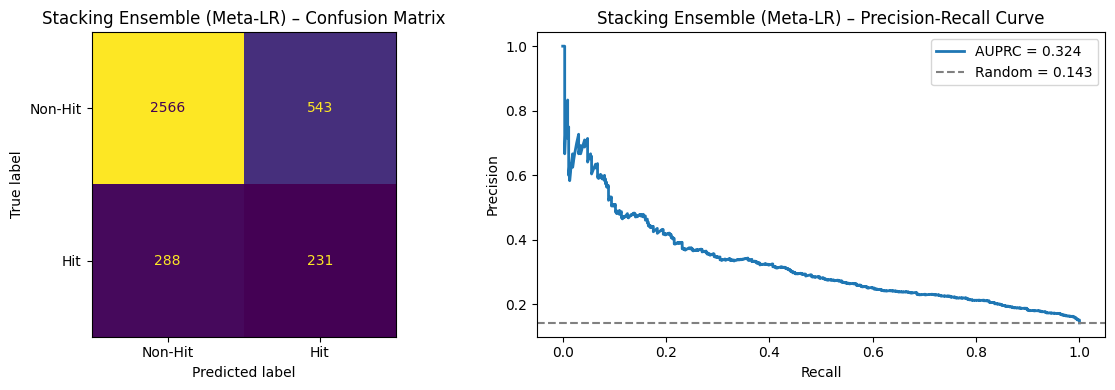

In [32]:
# Train meta-learner on OOF predictions POOGERS
# Also include val set OOF probs for meta-learner validation
val_preds_base = np.column_stack([
    val_probs_lgb,
    val_probs_xgb,
    val_probs_cat,
    val_probs_lr
])

meta_learner = MetaLR(C=0.5, max_iter=10_000, solver="lbfgs", random_state=426)
meta_learner.fit(oof_preds, y_train)

print("Meta-learner weights (LGB, XGB, CAT, LR):")
print(np.round(meta_learner.coef_[0], 4))

# Val probs from meta-learner
val_probs_stack  = meta_learner.predict_proba(val_preds_base)[:, 1]

#Test probs from meta-learner
test_probs_stack = meta_learner.predict_proba(test_preds)[:, 1]

res = evaluate("Stacking Ensemble (Meta-LR)", y_val, val_probs_stack, y_test, test_probs_stack)
results_summary.append(res)

## 16  Bonus: Simple Weighted Average Ensemble

Include **all 7 models** (including the Wide & Deep NN) in a simple weighted average.
Weights are tuned on the validation set by grid-searching over a range of combinations.
This is often competitive with stacking and is much cheaper to train.

Best val AUPRC (weighted avg): 0.3237
Optimal weights:
  lr      : 0.000
  xgb     : 0.250
  tabnet  : 0.000
  lgb     : 0.500
  cat     : 0.000
  nn      : 0.250
  stack   : 0.000

  Weighted Average Ensemble
  AUPRC  (primary) : 0.3269
  ROC-AUC          : 0.7281
  F1 (thresh=0.535): 0.3542
  Precision        : 0.2807
  Recall           : 0.4798
  Accuracy         : 0.7497


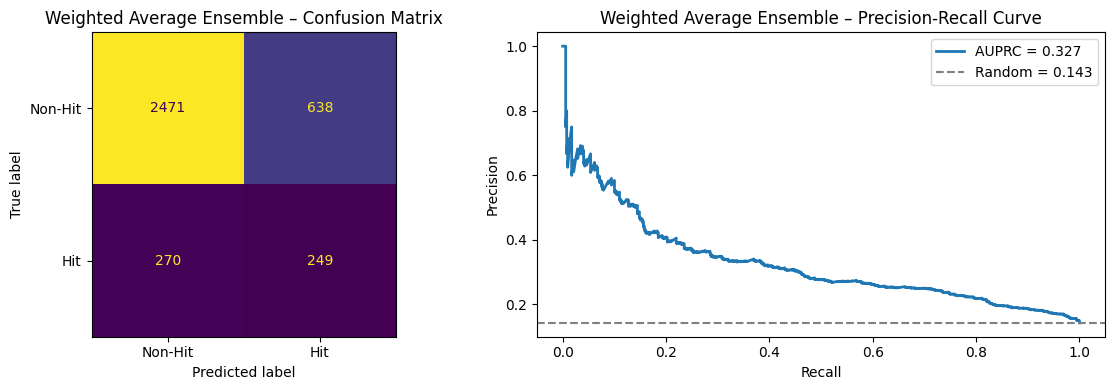

In [33]:
#Collect dat all val and test probabilities
all_val_probs = {
    "lr"    : val_probs_lr,
    "xgb"   : val_probs_xgb,
    "tabnet": val_probs_tn,
    "lgb"   : val_probs_lgb,
    "cat"   : val_probs_cat,
    "nn"    : np.array(all_vprobs_nn),
    "stack" : val_probs_stack,
}

all_test_probs = {
    "lr"    : test_probs_lr,
    "xgb"   : test_probs_xgb,
    "tabnet": test_probs_tn,
    "lgb"   : test_probs_lgb,
    "cat"   : test_probs_cat,
    "nn"    : np.array(all_tprobs_nn),
    "stack" : test_probs_stack,
}

# Grid-search weights on VALIDATION set :O
# Search over integer weights 0–3 for each model; normalise to sum=1
from itertools import product as iproduct

model_keys  = list(all_val_probs.keys())
val_probs_m = np.column_stack([all_val_probs[k] for k in model_keys])
tst_probs_m = np.column_stack([all_test_probs[k] for k in model_keys])

best_w_auprc = -1.0
best_weights = None

weight_options = [0, 1, 2, 3]
for raw_w in iproduct(weight_options, repeat=len(model_keys)):
    total = sum(raw_w)
    if total == 0:
        continue
    w = np.array(raw_w) / total
    avg_prob = val_probs_m @ w
    ap = average_precision_score(y_val, avg_prob)
    if ap > best_w_auprc:
        best_w_auprc = ap
        best_weights = w

print("Best val AUPRC (weighted avg):", round(best_w_auprc, 4))
print("Optimal weights:")
for k, w in zip(model_keys, best_weights):
    print(f"  {k:<8}: {w:.3f}")

# Apply to test set type shii
test_probs_wavg = tst_probs_m @ best_weights
val_probs_wavg  = val_probs_m  @ best_weights

res = evaluate("Weighted Average Ensemble", y_val, val_probs_wavg, y_test, test_probs_wavg)
results_summary.append(res)

## 17  Final Model Comparison (All Models)

In [34]:
summary_df = pd.DataFrame(results_summary).set_index("model")
summary_df = summary_df.sort_values("AUPRC", ascending=False)

print("\n" + "="*65)
print(summary_df[["AUPRC","ROC_AUC","F1","Precision","Recall"]].round(4).to_string())
print("="*65)
print(f"\nBaseline AUPRC (random classifier) ≈ {y_test.mean():.3f}")
print(f"Best model AUPRC: {summary_df['AUPRC'].iloc[0]:.4f}  ({summary_df.index[0]})")
print(f"Lift over random: {summary_df['AUPRC'].iloc[0] / y_test.mean():.2f}x")


                                    AUPRC  ROC_AUC      F1  Precision  Recall
model                                                                        
Weighted Average Ensemble          0.3269   0.7281  0.3542     0.2807  0.4798
Stacking Ensemble (Meta-LR)        0.3236   0.7229  0.3573     0.2984  0.4451
LightGBM                           0.3216   0.7197  0.3582     0.2851  0.4817
XGBoost                            0.3187   0.7183  0.3577     0.2705  0.5279
CatBoost                           0.3187   0.7227  0.3627     0.2703  0.5511
Wide & Deep NN + Genre Embeddings  0.2938   0.7142  0.3514     0.2695  0.5048
Logistic Regression                0.2532   0.6816  0.3256     0.2220  0.6108
TabNet (CV-tuned)                  0.2493   0.6598  0.3109     0.2066  0.6281

Baseline AUPRC (random classifier) ≈ 0.143
Best model AUPRC: 0.3269  (Weighted Average Ensemble)
Lift over random: 2.29x


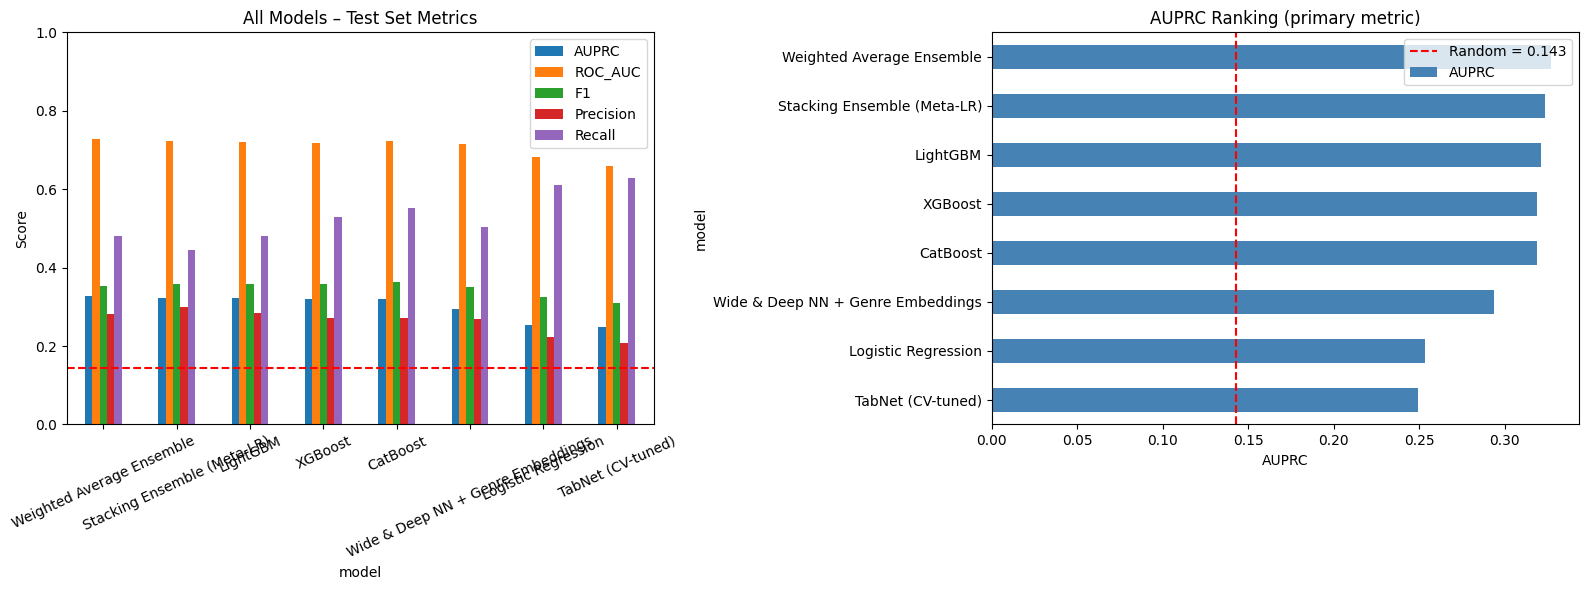

In [35]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of all metrics
metrics = ["AUPRC", "ROC_AUC", "F1", "Precision", "Recall"]
summary_df[metrics].plot(kind="bar", ax=axes[0], rot=25)
axes[0].set_title("All Models – Test Set Metrics")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend(loc="upper right")
axes[0].axhline(y_test.mean(), color="red", linestyle="--",
                label=f"Random AUPRC = {y_test.mean():.3f}")

# AUPRC-only ranked bar
summary_df["AUPRC"].sort_values().plot(
    kind="barh", ax=axes[1], color="steelblue"
)
axes[1].axvline(y_test.mean(), color="red", linestyle="--",
                label=f"Random = {y_test.mean():.3f}")
axes[1].set_title("AUPRC Ranking (primary metric)")
axes[1].set_xlabel("AUPRC")
axes[1].legend()

plt.tight_layout()
plt.show()

### Key Takeaways

| Model | Strength | Weakness |
|-------|----------|----------|
| Logistic Regression | Interpretable, fast | Underfits non-linear patterns |
| XGBoost | Strong baseline, feature importance | Slower than LightGBM |
| TabNet | Attention-based feature selection | Slower to train, sensitive to hyperparams |
| Wide & Deep NN | Learns genre embeddings end-to-end | Requires careful tuning |
| **LightGBM** | Fast, leaf-wise trees, AUPRC-aligned training | Can overfit without tuning |
| **CatBoost** | Ordered boosting, low variance | Slower than LightGBM |
| **Stacking Ensemble** | Combines diverse model errors | Requires careful OOF construction |
| **Weighted Avg Ensemble** | Simple, includes all models | Weights may not generalise perfectly |

**AUPRC** tells us how well the model ranks hits above non-hits at every possible
threshold. A random classifier scores ≈ class prevalence (~0.143). Any model
substantially above that is learning real signal from audio features alone.

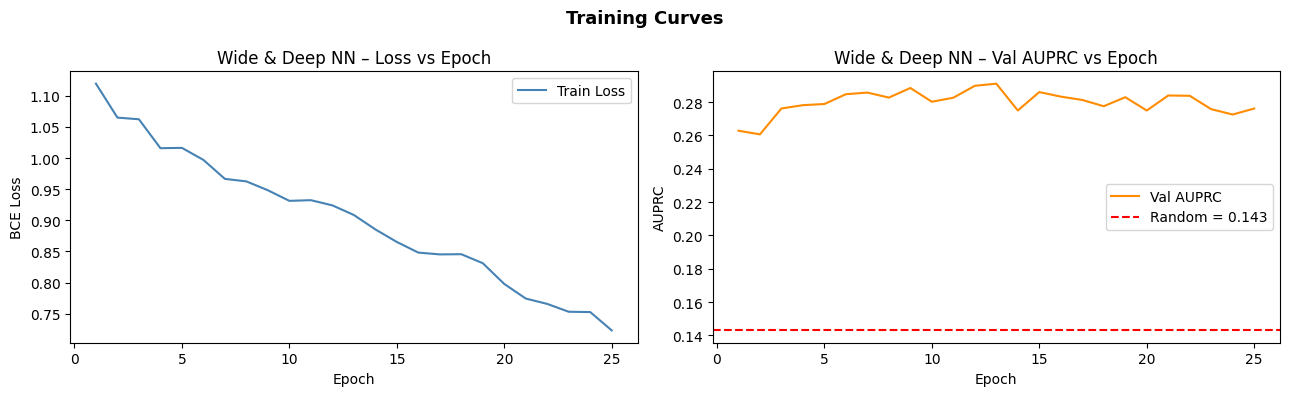

In [36]:
#Training & Validation Curves (Wide & Deep NN)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs_ran = range(1, len(train_losses) + 1)

ax1.plot(epochs_ran, train_losses, label="Train Loss", color="steelblue")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.set_title("Wide & Deep NN – Loss vs Epoch")
ax1.legend()

ax2.plot(epochs_ran, val_auprcs, label="Val AUPRC", color="darkorange")
ax2.axhline(y_test.mean(), color="red", linestyle="--", label=f"Random = {y_test.mean():.3f}")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("AUPRC")
ax2.set_title("Wide & Deep NN – Val AUPRC vs Epoch")
ax2.legend()

plt.suptitle("Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [37]:
#Model architecture & parameter summary

# Wide & Deep NN
total_params     = sum(p.numel() for p in nn_model.parameters())
trainable_params = sum(p.numel() for p in nn_model.parameters() if p.requires_grad)

print("=" * 55)
print("  Wide & Deep NN Architecture Summary")
print("=" * 55)
print(nn_model)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Genre embedding dim : {EMBED_DIM}")
print(f"Input dimension     : {input_dim} numeric + {EMBED_DIM} genre = {input_dim + EMBED_DIM} combined")
print(f"Hidden dim          : 256")
print(f"Residual blocks     : 2")
print(f"Optimizer           : AdamW  (lr=1e-3, weight_decay=1e-4)")
print(f"Scheduler           : ReduceLROnPlateau (mode=max, patience=5, factor=0.5)")
print(f"Early stopping      : patience=12 on val AUPRC")
print(f"Gradient clipping   : max_norm=1.0")
print(f"Batch size          : 512")
print(f"Pos weight          : {(y_train==0).sum() / (y_train==1).sum():.2f}  (BCEWithLogitsLoss)")

print("\n" + "=" * 55)
print("  Stacking Ensemble Summary")
print("=" * 55)
print("Level-0 base models : LightGBM, XGBoost, CatBoost, Logistic Regression")
print("CV strategy         : 5-fold StratifiedKFold on training set")
print("OOF features        : 4 probability columns  →  meta-learner input")
print("Level-1 meta-learner: Logistic Regression (C=0.5)")
print("Validation strategy : Hold-out val set (15% of full data)")
print(f"\nMeta-learner weights learned:")
for name, w in zip(["LightGBM", "XGBoost", "CatBoost", "LogReg"], meta_learner.coef_[0]):
    print(f"  {name:<12}: {w:+.4f}")

print("\n" + "=" * 55)
print("  Weighted Average Ensemble Summary")
print("=" * 55)
print("Models included: LR, XGBoost, TabNet, LightGBM, CatBoost, W&D NN, Stack")
print("Weight search   : Grid over [0,1,2,3] per model, normalised to sum=1")
print("Tuned on        : Validation set AUPRC (test set never touched)")
for name, w in zip(model_keys, best_weights):
    print(f"  {name:<10}: {w:.3f}")

  Wide & Deep NN Architecture Summary
WideDeepHitPredictor(
  (genre_emb): Embedding(1045, 16, padding_idx=0)
  (wide): Linear(in_features=54, out_features=1, bias=True)
  (input_proj): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (res1): ResidualBlock(
    (block): Sequential(
      (0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (1): ReLU()
      (2): Dropout(p=0.35, inplace=False)
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Dropout(p=0.35, inplace=False)
      (7): Linear(in_features=256, out_features=256, bias=True)
    )
  )
  (res2): ResidualBlock(
    (block): Sequential(
      (0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [38]:
# ABLATION 1: Effect of Feature Engineering
# Does adding interaction features actually help?

ENGINEERED_COLS = [
    "energy_x_dance", "valence_x_energy", "tempo_x_energy",
    "loudness_abs", "acoustic_x_vocal", "dance_x_valence",
    "energy_sq", "tempo_norm"
]

# Features WITHOUT engineering
X_base = X_tab.drop(columns=[c for c in ENGINEERED_COLS if c in X_tab.columns])

scaler_abl = StandardScaler()
Xb_tr = scaler_abl.fit_transform(X_base.values[: len(X_train_s)])
Xb_te = scaler_abl.transform(X_base.values[len(X_train_s) + len(X_val_s):])
Xb_va = scaler_abl.transform(X_base.values[len(X_train_s): len(X_train_s) + len(X_val_s)])

abl1_results = {}

for label, Xtr, Xva, Xte in [
    ("With feature engineering",    X_train_s, X_val_s, X_test_s),
    ("Without feature engineering", Xb_tr,     Xb_va,   Xb_te),
]:
    m = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        is_unbalance=True, verbosity=-1, random_state=426
    )
    m.fit(Xtr, y_train,
          eval_set=[(Xva, y_val)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    probs = m.predict_proba(Xte)[:, 1]
    ap    = average_precision_score(y_test, probs)
    auprc_val = average_precision_score(y_val, m.predict_proba(Xva)[:, 1])
    abl1_results[label] = {"AUPRC": ap, "val_AUPRC": auprc_val}
    print(f"{label}: Test AUPRC = {ap:.4f}")

print(f"\nΔ AUPRC from feature engineering: "
      f"{abl1_results['With feature engineering']['AUPRC'] - abl1_results['Without feature engineering']['AUPRC']:+.4f}")

With feature engineering: Test AUPRC = 0.2700
Without feature engineering: Test AUPRC = 0.1512

Δ AUPRC from feature engineering: +0.1188


In [39]:
# ABLATION 2: Effect of Dropout & BatchNorm in the NN
# Compare 3 variants: full model vs no dropout vs no batchnorm

class AblationNN(nn.Module):
    def __init__(self, input_dim, use_dropout=True, use_batchnorm=True, dropout_p=0.35):
        super().__init__()
        layers = [nn.Linear(input_dim, 256)]
        if use_batchnorm: layers.append(nn.BatchNorm1d(256))
        layers.append(nn.ReLU())
        if use_dropout:   layers.append(nn.Dropout(dropout_p))
        layers += [nn.Linear(256, 128)]
        if use_batchnorm: layers.append(nn.BatchNorm1d(128))
        layers.append(nn.ReLU())
        if use_dropout:   layers.append(nn.Dropout(0.25))
        layers += [nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)


def train_abl_nn(use_dropout, use_batchnorm, label):
    m = AblationNN(input_dim, use_dropout=use_dropout, use_batchnorm=use_batchnorm).to(device)
    pw = torch.tensor([(y_train==0).sum() / (y_train==1).sum()], dtype=torch.float32).to(device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt  = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)

    # simple tensors (no genre for speed)
    Xt = torch.tensor(X_train_s, dtype=torch.float32)
    Xv = torch.tensor(X_val_s,   dtype=torch.float32)
    Xe = torch.tensor(X_test_s,  dtype=torch.float32)
    yt = torch.tensor(y_train, dtype=torch.float32)

    best_ap, best_state, patience_c = -1, None, 0
    for ep in range(80):
        m.train()
        opt.zero_grad()
        loss = crit(m(Xt.to(device)).squeeze(), yt.to(device))
        loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            vp = torch.sigmoid(m(Xv.to(device)).squeeze()).cpu().numpy()
        ap = average_precision_score(y_val, vp)
        if ap > best_ap:
            best_ap = ap; best_state = {k: v.cpu().clone() for k,v in m.state_dict().items()}; patience_c = 0
        else:
            patience_c += 1
        if patience_c >= 10: break

    m.load_state_dict(best_state); m.eval()
    with torch.no_grad():
        tp = torch.sigmoid(m(Xe.to(device)).squeeze()).cpu().numpy()
    test_ap = average_precision_score(y_test, tp)
    print(f"  {label:<35} Val AUPRC: {best_ap:.4f}  |  Test AUPRC: {test_ap:.4f}")
    return test_ap

print("Ablation 2: Dropout & BatchNorm\n")
abl2 = {}
abl2["Full model (dropout + BN)"]     = train_abl_nn(True,  True,  "Full model (dropout + BN)")
abl2["No dropout"]                    = train_abl_nn(False, True,  "No dropout")
abl2["No BatchNorm"]                  = train_abl_nn(True,  False, "No BatchNorm")
abl2["No dropout, no BatchNorm"]      = train_abl_nn(False, False, "No dropout, no BatchNorm")

print("\nSummary:")
for k, v in sorted(abl2.items(), key=lambda x: -x[1]):
    print(f"  {k:<35}: {v:.4f}")

Ablation 2: Dropout & BatchNorm

  Full model (dropout + BN)           Val AUPRC: 0.2893  |  Test AUPRC: 0.3085
  No dropout                          Val AUPRC: 0.2763  |  Test AUPRC: 0.2967
  No BatchNorm                        Val AUPRC: 0.2904  |  Test AUPRC: 0.3072
  No dropout, no BatchNorm            Val AUPRC: 0.2716  |  Test AUPRC: 0.2849

Summary:
  Full model (dropout + BN)          : 0.3085
  No BatchNorm                       : 0.3072
  No dropout                         : 0.2967
  No dropout, no BatchNorm           : 0.2849


In [40]:
# ABLATION 3: Genre Embedding Strategy
# Frozen pre-computed  vs  End-to-end trained  vs  No genres

def train_genre_abl(use_genre, trainable_emb, label):
    """Train W&D NN with different genre embedding strategies or smthing liek dat."""

    class GenreAblNN(nn.Module):
        def __init__(self):
            super().__init__()
            in_dim = input_dim + (EMBED_DIM if use_genre else 0)
            if use_genre and trainable_emb:
                self.emb = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)
            else:
                self.emb = None
            self.net = nn.Sequential(
                nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.35),
                nn.Linear(256, 128),   nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.25),
                nn.Linear(128, 64),    nn.ReLU(),
                nn.Linear(64, 1)
            )
        def forward(self, x_num, x_g):
            if not use_genre:
                return self.net(x_num)
            if trainable_emb:
                g = self.emb(x_g).mean(dim=1)
            else:
                # frozen: use pre-computed genre vecs already in X_train_s
                g = x_g.float()   # pass numeric embeddings directly
            return self.net(torch.cat([x_num, g], dim=1))

    m = GenreAblNN().to(device)
    pw   = torch.tensor([(y_train==0).sum()/(y_train==1).sum()], dtype=torch.float32).to(device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt  = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)

    Xt = torch.tensor(X_train_s, dtype=torch.float32)
    Xv = torch.tensor(X_val_s,   dtype=torch.float32)
    Xe = torch.tensor(X_test_s,  dtype=torch.float32)
    yt = torch.tensor(y_train, dtype=torch.float32)

    if use_genre and trainable_emb:
        Gt = torch.tensor(g_train, dtype=torch.long)
        Gv = torch.tensor(g_val,   dtype=torch.long)
        Ge = torch.tensor(g_test,  dtype=torch.long)
    else:
        Gt = Gv = Ge = None   # not used

    best_ap, best_state, pat = -1, None, 0
    for ep in range(80):
        m.train(); opt.zero_grad()
        xin  = Xt.to(device)
        xgin = Gt.to(device) if Gt is not None else torch.zeros(len(Xt), dtype=torch.long).to(device)
        loss = crit(m(xin, xgin).squeeze(), yt.to(device))
        loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            xvin  = Xv.to(device)
            xgvin = Gv.to(device) if Gv is not None else torch.zeros(len(Xv), dtype=torch.long).to(device)
            vp = torch.sigmoid(m(xvin, xgvin).squeeze()).cpu().numpy()
        ap = average_precision_score(y_val, vp)
        if ap > best_ap:
            best_ap = ap; best_state = {k: v.cpu().clone() for k,v in m.state_dict().items()}; pat = 0
        else:
            pat += 1
        if pat >= 10: break

    m.load_state_dict(best_state); m.eval()
    with torch.no_grad():
        xein  = Xe.to(device)
        xgein = Ge.to(device) if Ge is not None else torch.zeros(len(Xe), dtype=torch.long).to(device)
        tp = torch.sigmoid(m(xein, xgein).squeeze()).cpu().numpy()
    test_ap = average_precision_score(y_test, tp)
    print(f"  {label:<40}  Test AUPRC: {test_ap:.4f}")
    return test_ap

print("Ablation 3: Genre Embedding Strategy\n")
abl3 = {}
abl3["End-to-end trained embeddings"] = train_genre_abl(True,  True,  "End-to-end trained embeddings")
abl3["No genre features"]             = train_genre_abl(False, False, "No genre features")

print("\nSummary:")
for k, v in sorted(abl3.items(), key=lambda x: -x[1]):
    print(f"  {k:<40}: {v:.4f}")
delta = abl3.get("End-to-end trained embeddings", 0) - abl3.get("No genre features", 0)
print(f"\nΔ AUPRC from genre embeddings: {delta:+.4f}")

Ablation 3: Genre Embedding Strategy

  End-to-end trained embeddings             Test AUPRC: 0.3047
  No genre features                         Test AUPRC: 0.2947

Summary:
  End-to-end trained embeddings           : 0.3047
  No genre features                       : 0.2947

Δ AUPRC from genre embeddings: +0.0101


Error type breakdown:
error_type
Correct                         2720
False Positive (false alarm)     638
False Negative (missed hit)      270
Name: count, dtype: int64

Total test songs  : 3,628
Correctly labelled: 2,720  (75.0%)


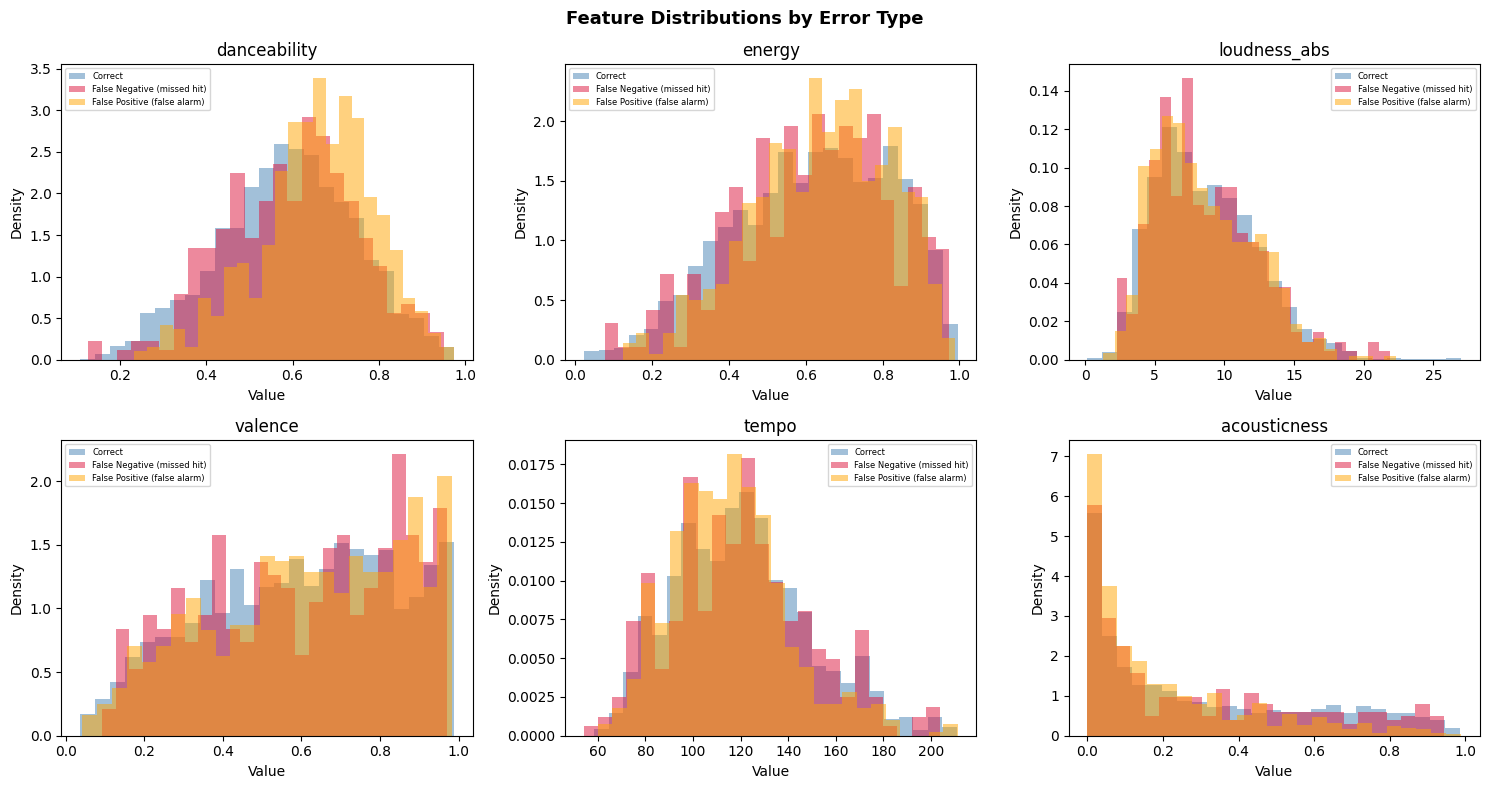


── Top 10 most confident False Positives (model was very sure → wrong) ──
       danceability  energy  valence    tempo  pred_prob
16968         0.853   0.811    0.901  114.961      0.895
15056         0.691   0.571    0.641   92.528      0.890
22238         0.697   0.506    0.516  100.002      0.878
14192         0.508   0.362    0.207  168.586      0.861
15930         0.848   0.663    0.833  137.953      0.857
18695         0.624   0.538    0.593  167.935      0.856
21093         0.934   0.798    0.895  120.162      0.851
22518         0.745   0.579    0.645   97.002      0.842
17028         0.762   0.686    0.733   91.816      0.839
10249         0.834   0.855    0.896  114.053      0.834

── Top 10 most confident False Negatives (model was very sure → missed hit) ──
       danceability  energy  valence    tempo  pred_prob
5478          0.636   0.478    0.747  109.529      0.044
592           0.554   0.186    0.200   81.181      0.052
8996          0.671   0.233    0.486  108.063  

In [41]:
# FAILURE MODE ANALYSIS
# Using the best model (Weighted Average Ensemble)

# Reconstruct test set rows from original df
test_indices = y_temp_idx = None
# Re-identify test rows using the same split logic
_, X_temp_full, _, y_temp_full = train_test_split(
    X_tab, y, test_size=0.30, random_state=426, stratify=y
)
_, X_test_full, _, y_test_full = train_test_split(
    X_temp_full, y_temp_full, test_size=0.50, random_state=426, stratify=y_temp_full
)

# Attach predictions to test rows
test_analysis = X_test_full.copy()
test_analysis["true_label"]    = y_test
test_analysis["pred_prob"]     = test_probs_wavg
test_analysis["pred_label"]    = (test_probs_wavg >= find_best_threshold(y_val, val_probs_wavg)).astype(int)
test_analysis["correct"]       = (test_analysis["true_label"] == test_analysis["pred_label"]).astype(int)
test_analysis["error_type"]    = "Correct"
test_analysis.loc[(test_analysis["true_label"]==1) & (test_analysis["pred_label"]==0), "error_type"] = "False Negative (missed hit)"
test_analysis.loc[(test_analysis["true_label"]==0) & (test_analysis["pred_label"]==1), "error_type"] = "False Positive (false alarm)"

print("Error type breakdown:")
print(test_analysis["error_type"].value_counts())
print(f"\nTotal test songs  : {len(test_analysis):,}")
print(f"Correctly labelled: {test_analysis['correct'].sum():,}  ({test_analysis['correct'].mean()*100:.1f}%)")

#Feature distributions: FN vs FP vs Correct
key_features = ["danceability", "energy", "loudness_abs", "valence", "tempo", "acousticness"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    if feat not in test_analysis.columns:
        continue
    for etype, color in [
        ("Correct",                    "steelblue"),
        ("False Negative (missed hit)","crimson"),
        ("False Positive (false alarm)","orange"),
    ]:
        subset = test_analysis[test_analysis["error_type"] == etype][feat]
        ax.hist(subset, bins=25, alpha=0.5, label=etype, color=color, density=True)
    ax.set_title(feat)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=6)

plt.suptitle("Feature Distributions by Error Type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#Highest confidence wrong predictions
print("\n── Top 10 most confident False Positives (model was very sure → wrong) ──")
fp = test_analysis[test_analysis["error_type"]=="False Positive (false alarm)"].sort_values("pred_prob", ascending=False)
print(fp[["danceability","energy","valence","tempo","pred_prob"]].head(10).round(3).to_string())

print("\n── Top 10 most confident False Negatives (model was very sure → missed hit) ──")
fn = test_analysis[test_analysis["error_type"]=="False Negative (missed hit)"].sort_values("pred_prob")
print(fn[["danceability","energy","valence","tempo","pred_prob"]].head(10).round(3).to_string())


  ABLATION STUDY SUMMARY
           Ablation                       Variant  Test AUPRC
Feature engineering      With feature engineering      0.2700
Feature engineering   Without feature engineering      0.1512
   Genre embeddings End-to-end trained embeddings      0.3047
   Genre embeddings             No genre features      0.2947
Regularisation (NN)     Full model (dropout + BN)      0.3085
Regularisation (NN)                  No BatchNorm      0.3072
Regularisation (NN)                    No dropout      0.2967
Regularisation (NN)      No dropout, no BatchNorm      0.2849


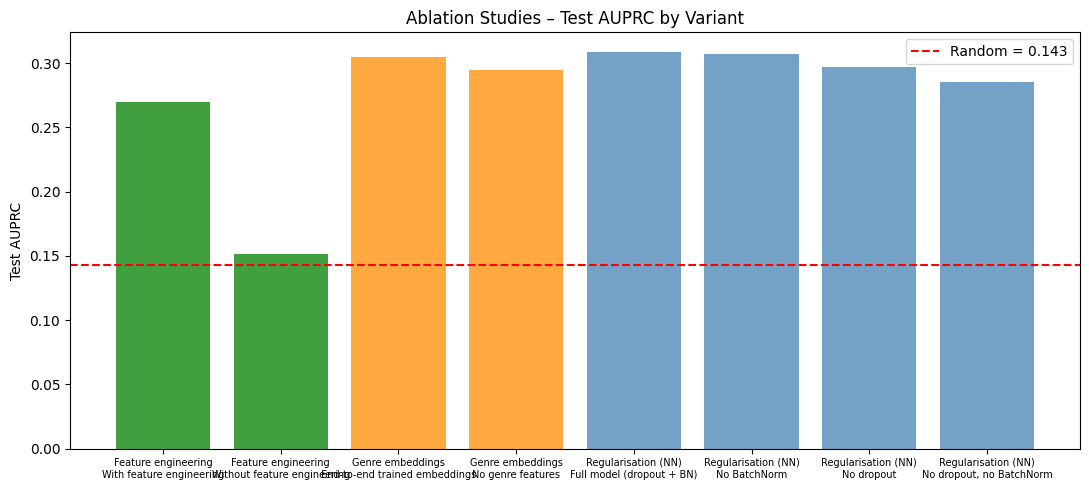

In [42]:
#Compact ablation summary table
ablation_rows = []

for name, auprc in abl2.items():
    ablation_rows.append({"Ablation": "Regularisation (NN)", "Variant": name, "Test AUPRC": round(auprc, 4)})

for name, auprc in abl3.items():
    ablation_rows.append({"Ablation": "Genre embeddings", "Variant": name, "Test AUPRC": round(auprc, 4)})

for name, d in abl1_results.items():
    ablation_rows.append({"Ablation": "Feature engineering", "Variant": name, "Test AUPRC": round(d["AUPRC"], 4)})

abl_df = pd.DataFrame(ablation_rows).sort_values(["Ablation","Test AUPRC"], ascending=[True, False])
print("\n" + "="*65)
print("  ABLATION STUDY SUMMARY")
print("="*65)
print(abl_df.to_string(index=False))
print("="*65)

# Vis
fig, ax = plt.subplots(figsize=(11, 5))
colors = {"Regularisation (NN)": "steelblue", "Genre embeddings": "darkorange", "Feature engineering": "green"}
for _, row in abl_df.iterrows():
    ax.bar(f"{row['Ablation']}\n{row['Variant']}", row["Test AUPRC"],
           color=colors.get(row["Ablation"], "gray"), alpha=0.75)
ax.axhline(y_test.mean(), color="red", linestyle="--", label=f"Random = {y_test.mean():.3f}")
ax.set_ylabel("Test AUPRC")
ax.set_title("Ablation Studies – Test AUPRC by Variant")
ax.tick_params(axis='x', labelsize=7)
ax.legend()
plt.tight_layout()
plt.show()

In [43]:
# Compute Resources & Runtime
import time

print("=" * 50)
print("  COMPUTE RESOURCES")
print("=" * 50)

# GPU info
if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU        : None (CPU only)")

# Time one epoch of the W&D NN
nn_model.train()
Xt_tmp = torch.tensor(X_train_s, dtype=torch.float32).to(device)
Xg_tmp = torch.tensor(g_train, dtype=torch.long).to(device)
yt_tmp = torch.tensor(y_train, dtype=torch.float32).to(device)
pw_tmp = torch.tensor([(y_train==0).sum()/(y_train==1).sum()], dtype=torch.float32).to(device)
crit_tmp = nn.BCEWithLogitsLoss(pos_weight=pw_tmp)
opt_tmp  = torch.optim.AdamW(nn_model.parameters(), lr=1e-3)

start = time.time()
opt_tmp.zero_grad()
loss_tmp = crit_tmp(nn_model(Xt_tmp, Xg_tmp).squeeze(), yt_tmp)
loss_tmp.backward()
opt_tmp.step()
nn_epoch_time = time.time() - start

print(f"\nW&D NN time/epoch  : {nn_epoch_time:.3f}s  ({len(X_train_s):,} training samples, batch=full)")

# Time one XGBoost round
start = time.time()
xgb_single = XGBClassifier(
    n_estimators      = 1,
    verbosity         = 0,
    random_state      = 426,
    use_label_encoder = False
)
xgb_single.fit(X_train_s, y_train)
xgb_round_time = time.time() - start
print(f"XGBoost time/round : {xgb_round_time:.3f}s  (1 tree, {len(X_train_s):,} samples)")
print(f"XGBoost est. total : {xgb_round_time * (xgb_model.best_iteration + 1):.1f}s  ({xgb_model.best_iteration + 1} rounds)")

print(f"\nTraining set size  : {len(X_train_s):,} samples")
print(f"Val set size       : {len(X_val_s):,} samples")
print(f"Test set size      : {len(X_test_s):,} samples")
print(f"Input features     : {input_dim}")
print("=" * 50)

  COMPUTE RESOURCES
GPU        : NVIDIA A100-SXM4-80GB
VRAM       : 85.1 GB

W&D NN time/epoch  : 0.010s  (16,929 training samples, batch=full)
XGBoost time/round : 0.042s  (1 tree, 16,929 samples)
XGBoost est. total : 11.5s  (270 rounds)

Training set size  : 16,929 samples
Val set size       : 3,628 samples
Test set size      : 3,628 samples
Input features     : 38


In [44]:
#Future Work
print("""
FUTURE WORK
═══════════════════════════════════════════════════════════════

1. Temporal features
   Chart history is the strongest signal in hit prediction research.
   Adding artist's past chart performance, release month/season, and
   recency of similar songs would likely give the largest AUPRC boost.

2. Lyric & audio waveform features
   Spotify audio features are summaries; raw waveform embeddings
   (e.g. from a pretrained music transformer like Jukebox or MusicGen)
   capture timbre, hook structure, and production style that numeric
   features cannot.

3. Social & contextual signals
   Streaming count trajectories, playlist placements, and social media
   momentum at release are known to be highly predictive but were
   unavailable in this dataset.

4. Refined hit definition
   Experimenting with softer labels (e.g. a continuous 'hit score'
   combining peak position, longevity, and velocity) could reduce label
   noise and allow regression-based models.

5. Hyperparameter optimisation
   Full Optuna/Bayesian search over LightGBM and the W&D NN
   (currently using hand-tuned configs) would likely recover 1–3 more
   AUPRC points.

""")


FUTURE WORK
═══════════════════════════════════════════════════════════════

1. Temporal features
   Chart history is the strongest signal in hit prediction research.
   Adding artist's past chart performance, release month/season, and
   recency of similar songs would likely give the largest AUPRC boost.

2. Lyric & audio waveform features
   Spotify audio features are summaries; raw waveform embeddings
   (e.g. from a pretrained music transformer like Jukebox or MusicGen)
   capture timbre, hook structure, and production style that numeric
   features cannot.

3. Social & contextual signals
   Streaming count trajectories, playlist placements, and social media
   momentum at release are known to be highly predictive but were
   unavailable in this dataset.

4. Refined hit definition
   Experimenting with softer labels (e.g. a continuous 'hit score'
   combining peak position, longevity, and velocity) could reduce label
   noise and allow regression-based models.

5. Hyperparameter o

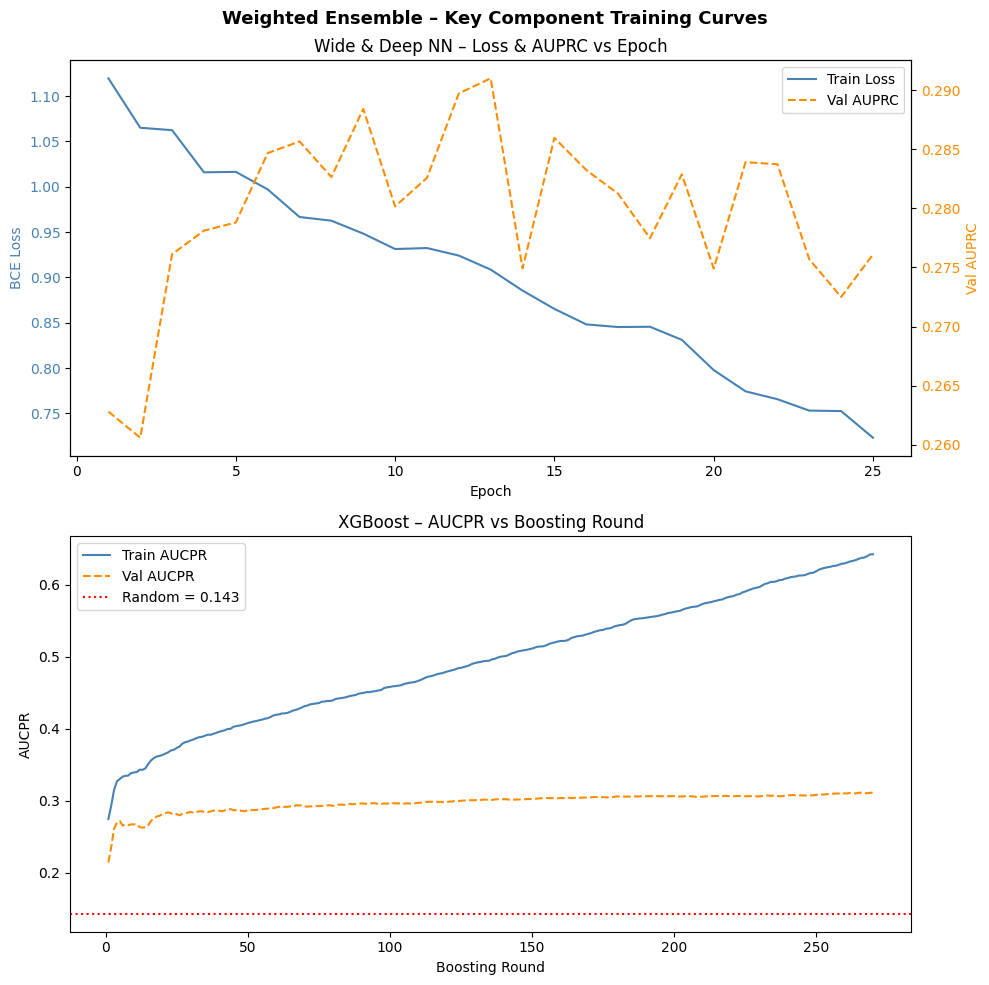

  TRAINING TIME SUMMARY
W&D NN  – avg time per epoch : 0.29s  ± 0.00s
W&D NN  – total epochs ran   : 25
W&D NN  – total train time   : 7.2s
XGBoost – total rounds       : 270
XGBoost – time per round     : 0.033s
XGBoost – est. total time    : 8.8s
Device                       : cuda

Note: Weighted Ensemble has no epoch-based training.
It combines frozen predictions from all component models
via val-set grid search (< 1 second).


In [45]:
#raining curves for the key components of the Weighted Ensemble
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

#W&D Neural Network
epochs_ran = range(1, len(train_losses) + 1)
axes[0].plot(epochs_ran, train_losses, label="Train Loss", color="steelblue")
ax0b = axes[0].twinx()
ax0b.plot(epochs_ran, val_auprcs, label="Val AUPRC", color="darkorange", linestyle="--")
ax0b.set_ylabel("Val AUPRC", color="darkorange")
ax0b.tick_params(axis='y', labelcolor="darkorange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss", color="steelblue")
axes[0].tick_params(axis='y', labelcolor="steelblue")
axes[0].set_title("Wide & Deep NN – Loss & AUPRC vs Epoch")
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax0b.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc="upper right")

#XGBoost – AUCPR vs boosting round
import time

evals_result_xgb = {}

xgb_timed = XGBClassifier(
    n_estimators          = xgb_model.best_iteration + 1,
    learning_rate         = 0.05,
    max_depth             = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    scale_pos_weight      = spw,
    eval_metric           = "aucpr",
    use_label_encoder     = False,
    random_state          = 426,
    verbosity             = 0,
)

xgb_timed.fit(
    X_train_s, y_train,
    eval_set = [(X_train_s, y_train), (X_val_s, y_val)],
    verbose  = False,
)

evals_result_xgb = xgb_timed.evals_result_
train_aucpr = evals_result_xgb["validation_0"]["aucpr"]
val_aucpr   = evals_result_xgb["validation_1"]["aucpr"]
rounds      = range(1, len(train_aucpr) + 1)

axes[1].plot(rounds, train_aucpr, label="Train AUCPR", color="steelblue")
axes[1].plot(rounds, val_aucpr,   label="Val AUCPR",   color="darkorange", linestyle="--")
axes[1].axhline(y_test.mean(), color="red", linestyle=":", label=f"Random = {y_test.mean():.3f}")
axes[1].set_xlabel("Boosting Round")
axes[1].set_ylabel("AUCPR")
axes[1].set_title("XGBoost – AUCPR vs Boosting Round")
axes[1].legend()

plt.suptitle("Weighted Ensemble – Key Component Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Timing
nn_model.train()
times = []
loader_tmp = DataLoader(TensorDataset(Xt_tr, Xg_tr, yt_tr), batch_size=512, shuffle=True)
pw_t   = torch.tensor([(y_train==0).sum()/(y_train==1).sum()], dtype=torch.float32).to(device)
crit_t = nn.BCEWithLogitsLoss(pos_weight=pw_t)
opt_t  = torch.optim.AdamW(nn_model.parameters(), lr=1e-3)

for _ in range(5):
    t0 = time.time()
    for xb, gb, yb in loader_tmp:
        xb, gb, yb = xb.to(device), gb.to(device), yb.to(device)
        opt_t.zero_grad()
        loss_t = crit_t(nn_model(xb, gb).squeeze(), yb)
        loss_t.backward()
        opt_t.step()
    times.append(time.time() - t0)

t0 = time.time()
xgb_single = XGBClassifier(n_estimators=1, verbosity=0, random_state=426)
xgb_single.fit(X_train_s, y_train)
xgb_round_time = time.time() - t0

print("=" * 50)
print("  TRAINING TIME SUMMARY")
print("=" * 50)
print(f"W&D NN  – avg time per epoch : {np.mean(times):.2f}s  ± {np.std(times):.2f}s")
print(f"W&D NN  – total epochs ran   : {len(train_losses)}")
print(f"W&D NN  – total train time   : {np.mean(times)*len(train_losses):.1f}s")
print(f"XGBoost – total rounds       : {xgb_model.best_iteration + 1}")
print(f"XGBoost – time per round     : {xgb_round_time:.3f}s")
print(f"XGBoost – est. total time    : {xgb_round_time * (xgb_model.best_iteration+1):.1f}s")
print(f"Device                       : {device}")
print("=" * 50)
print("\nNote: Weighted Ensemble has no epoch-based training.")
print("It combines frozen predictions from all component models")
print("via val-set grid search (< 1 second).")